In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent  # 假设 Notebook 在项目根目录的 notebooks 子目录中
sys.path.append(str(project_root))
import numpy as np
import pickle
import matplotlib.pyplot as plt
from src.models import rsm_wsgg as rsm
from src.models import wang_wsgg as wang
from src.models import wsgg as wsgg
from src.get_emis_abso import get_emis_abso
import src.gas_rte_solver as solver
from src.utils import setup_device
import torch
from matplotlib.ticker import AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.constants import Stefan_Boltzmann
from scipy.constants import sigma
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error
from src.models.wsgg_model import WSGGModel
import importlib
importlib.reload(rsm)
importlib.reload(wang)
importlib.reload(wsgg)
importlib.reload(solver)
import glob
import os
import re

Ng = 6  # WSGG模型中灰气体数量
Pt = 1.0  # 总压 bar
Exp = 4 # 多项式指数
T_ref = 1000 # 参考温度
X = 0.2

# 设置设备
device = setup_device()

# 存储摩尔分数、温度、路径长度及对应发射率的文件名
filename = '../input/MixEmiss_p1.0_X0.2_Mr0.1-4.0_40_T40_path40.npy'
# 调用load_and_process_emissivity_data载入发射率数据
mole_fraction_ratios, temperatures, path_lengths, epsilon_3d = rsm.load_and_process_emissivity_data(filename)
beta, gamma = rsm.read_from_excel(filename='../results/coefficients_20260326_122927_Ng6_Exp4_Tref1000_bs16384.xlsx')
# rsm.print_formatted_arrays(beta, gamma)

Using device: cuda


# 验证 RSM_WSGG 模型的发射率计算精度

In [2]:
def predict_with_model(beta, gamma, Mr_array, T_array, L_array):
    """
    使用训练好的系数预测发射率
    
    参数:
    beta (array): 权重系数 (形状: [Ng, 15])
    gamma (array): 吸收系数 (形状: [Ng, Exp+1])
    Mr_array (array): 摩尔分数比数组
    T_array (array): 温度数组(K)
    L_array (array): 路径长度数组(m)
    
    返回:
    numpy.ndarray: 预测的发射率3D数组
    """
    # 创建网格
    Mr_grid, T_grid, L_grid = np.meshgrid(Mr_array, T_array, L_array, indexing='ij')
    
    # 展平并转换为Tensor
    Mr_flat = torch.tensor(Mr_grid.ravel(), dtype=torch.float32, device=device)
    Tr_flat = torch.tensor(T_grid.ravel() / T_ref, dtype=torch.float32, device=device)
    L_flat = torch.tensor(L_grid.ravel(), dtype=torch.float32, device=device)
    
    # 初始化模型
    model = WSGGModel(Ng=Ng, Exp=Exp, Pt=Pt, X=X, T_ref=T_ref).to(device)
    
    # 加载训练好的参数
    with torch.no_grad():
        model.beta.data.copy_(torch.tensor(beta, device=device))
        model.gamma.data.copy_(torch.tensor(gamma, device=device))
    
    # 预测发射率
    with torch.no_grad():
        epsilon_flat = model(Mr_flat, Tr_flat, L_flat)
    
    # 重塑为3D形状
    return epsilon_flat.cpu().numpy().reshape(Mr_grid.shape)

In [3]:
def calculate_wang_emissivity_3d(file_path, sheet_name, mole_fraction_ratios, temperatures, path_lengths, Pt, gas_species=4):
    """
    计算三维发射率矩阵基于Wang的系数方法
    
    参数:
    file_path (str): 系数文件路径
    sheet_name (str): 工作表名称
    mole_fraction_ratios (array-like): 摩尔分数比数组
    temperatures (array-like): 温度数组(K)
    path_lengths (array-like): 路径长度数组(m)
    Pt (float): 总压力(bar)
    gas_species (int, optional): 灰气体种类数量，wang模型默认为4
    
    返回:
    numpy.ndarray: 三维发射率矩阵，形状为(len(mole_fraction_ratios), len(temperatures), len(path_lengths))
    """
    # 读取系数和范围数据
    coefficients, range_dict = wang.read_coefficients_with_ranges(file_path, sheet_name=sheet_name)
    
    # 初始化3D发射率矩阵
    epsilon_3d = np.zeros((len(mole_fraction_ratios), len(temperatures), len(path_lengths)))
    
    # 三维参数空间遍历计算
    for i, Mr in enumerate(mole_fraction_ratios):
        for j, Tgas in enumerate(temperatures):
            for k, path_length in enumerate(path_lengths):
                # 获取吸收系数和权重
                a, K = wang.get_k_a(Tgas, Mr, gas_species, coefficients, range_dict)
                # 计算发射率epsilon
                epsilon_3d[i, j, k] = sum(a_i * (1 - np.exp(-K_i * Pt * path_length)) for a_i, K_i in zip(a, K))
                
    return epsilon_3d

In [4]:
def calculate_rsm_emissivity_3d(mole_fraction_ratios, temperatures, path_lengths, 
                                Pt, X, T_ref, Ng, Exp, beta, gamma):
    """
    计算三维发射率矩阵基于RSM（响应面）方法
    
    参数:
    mole_fraction_ratios (array-like): 摩尔分数比数组
    temperatures (array-like): 温度数组(K)
    path_lengths (array-like): 路径长度数组(m)
    Pt (float): 总压力(bar)
    X (float): 压力-路径修正因子
    T_ref (float): 参考温度(K)
    Ng (int): 光谱带数量
    Exp (array-like): 指数系数数组
    beta (array-like): 吸收系数参数数组
    gamma (array-like): 谱线展宽参数数组
    
    返回:
    numpy.ndarray: 三维发射率矩阵，形状为(len(mole_fraction_ratios), len(temperatures), len(path_lengths))
    """
    # 初始化3D发射率矩阵
    epsilon_3d = np.zeros((len(mole_fraction_ratios), len(temperatures), len(path_lengths)))
    
    # 三维参数空间遍历计算
    for i, Mr in enumerate(mole_fraction_ratios):
        for j, Tgas in enumerate(temperatures):
            Tr = Tgas / T_ref  # 计算归一化温度
            for k, path_length in enumerate(path_lengths):
                # 获取吸收系数和权重
                a, K = rsm.get_k_a_ML(Tr, Mr, Ng, Exp, beta, gamma)
                
                # 计算当前参数的发射率
                epsilon_3d[i, j, k] = sum(a_i * (1 - np.exp(-K_i * Pt * X * path_length)) for a_i, K_i in zip(a, K))
                
    return epsilon_3d

In [5]:
# 自定义 R² 函数
def r2(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))

# KDE 散点图函数
def kde_scatter(x, y, fig, ax, min_max=[0, 1]):
    LBL = x
    MLP = y

    xy = np.vstack([MLP, LBL])
    z = gaussian_kde(xy)(xy)
    z = (z - np.min(z)) / (np.max(z) - np.min(z))
    idx = z.argsort()
    MMLP, LLBL, z = MLP[idx], LBL[idx], z[idx]

    if min_max is None:
        min_value = 0.99 * np.min(LBL)
        max_value = 1.01 * np.max(LBL)
    else:
        min_value, max_value = min_max
    xyline = np.linspace(min_value, max_value, 61)

    ax.set_ylabel('Total Emissivity (Reference)')
    ax.set_xlabel('Predicted Total Emissivity')
    ax.axis([min_value, max_value, min_value, max_value])
    ax.set_aspect(1.0)
    text1 = f'N: {len(LBL)}'
    R2_test = r2(LBL, MLP)
    text2 = f'R²: {R2_test:.4f}'
    text3 = f'ME: {np.mean(LBL - MLP):.4f}'
    text4 = f'RMSE: {np.sqrt(mean_squared_error(LBL, MLP)):.4f}'
    ax.plot(xyline, xyline, 'r-', label=r'Ideal', linewidth=2)
    ax.fill_between(xyline, xyline * 1.01, xyline * 0.99,
                    alpha=0.5, edgecolor='0.4', facecolor='0.4',
                    linewidth=1, linestyle='--', antialiased=True)
    cf = ax.scatter(LLBL, MMLP, c=z, s=3, alpha=1.0)
    fig.colorbar(cf, label='Density', ax=ax)

    ax.set_xlim([min_value, max_value])
    ax.set_ylim([min_value, max_value])

    z0 = 0.97
    dz = 0.07
    ax.text(0.02, z0, text1, ha='left', va='top', transform=ax.transAxes, fontsize=9)
    ax.text(0.02, z0 - dz, text2, ha='left', va='top', transform=ax.transAxes, fontsize=9)
    ax.text(0.02, z0 - dz * 2, text3, ha='left', va='top', transform=ax.transAxes, fontsize=9)
    ax.text(0.02, z0 - dz * 3, text4, ha='left', va='top', transform=ax.transAxes, fontsize=9)
    return fig, ax

# 计算误差阈值内的数据点百分比
def calculate_error_thresholds(y_true, y_pred, thresholds=[0.05, 0.10]):
    errors = np.abs(y_true - y_pred) / y_true
    results = {}
    for threshold in thresholds:
        within_threshold = np.sum(errors <= threshold)
        percentage = (within_threshold / len(y_true)) * 100
        results[f"{threshold*100}%"] = percentage
    return results

Percentage of data points within 5.0% error threshold: 99.49%
Percentage of data points within 10.0% error threshold: 100.00%

Model Coefficients:
Beta Coefficients (shape: (7, 15)):
First row: [-2.532444  -0.153028   0.9164084 -0.5088174  0.2441467] ...
Gamma Coefficients (shape: (7, 5)):
First row: [0. 0. 0.] ...


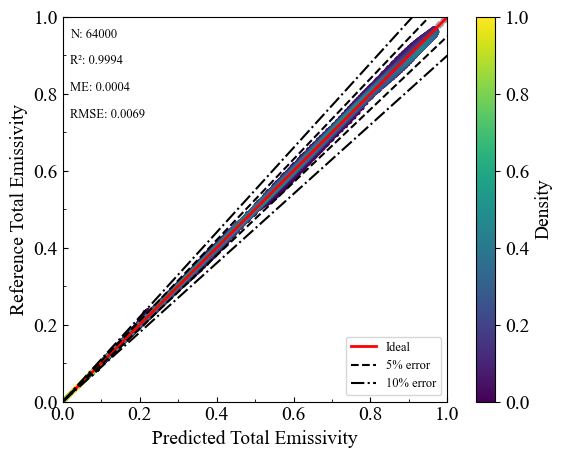

In [6]:
# 设置全局字体为Times New Roman，并设置数学字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # 使用STIX字体，它与Times New Roman兼容
plt.rcParams['mathtext.rm'] = 'Times New Roman'  # 设置数学字体中的罗马字体为Times New Roman
plt.rcParams['font.size'] = 14

# 使用模型预测发射率
epsilon_pred = predict_with_model(beta, gamma, mole_fraction_ratios, temperatures, path_lengths)

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制散点图
kde_scatter(epsilon_3d.flatten(), epsilon_pred.flatten(), fig, ax, min_max=[0, 1])

# 绘制误差线
plt.plot([0, 1], [0, 1.05], 'k--', label='5% error')  # 上限
plt.plot([0, 1], [0, 0.95], 'k--', label='_nolegend_')  # 下限
plt.plot([0, 1], [0, 1.10], 'k-.', label='10% error')  # 上限
plt.plot([0, 1], [0, 0.90], 'k-.', label='_nolegend_')  # 下限

# 设置刻度线向内，并添加次要刻度
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='both', direction='in')

# 设置标签和图例
plt.legend(loc='lower right', prop={'size': 9})
plt.xlabel('Predicted Total Emissivity')
plt.ylabel('Reference Total Emissivity')

# 自动调整子图间距
plt.tight_layout()

# 保存图片
plt.savefig('../results/img/kde_scatter_plot_wsgg.png', bbox_inches='tight', dpi=300)
# plt.close()

# 计算并打印误差百分比
error_thresholds = calculate_error_thresholds(epsilon_3d.flatten(), epsilon_pred.flatten())
for threshold, percentage in error_thresholds.items():
    print(f"Percentage of data points within {threshold} error threshold: {percentage:.2f}%")

# 打印模型系数
print("\nModel Coefficients:")
# 创建打印预览（不完整打印）
print(f"Beta Coefficients (shape: {beta.shape}):")
print("First row:", beta[0, :5], "...")  # 仅显示前5个值
print(f"Gamma Coefficients (shape: {gamma.shape}):")
print("First row:", gamma[0, :3], "...")  # 仅显示前3个值

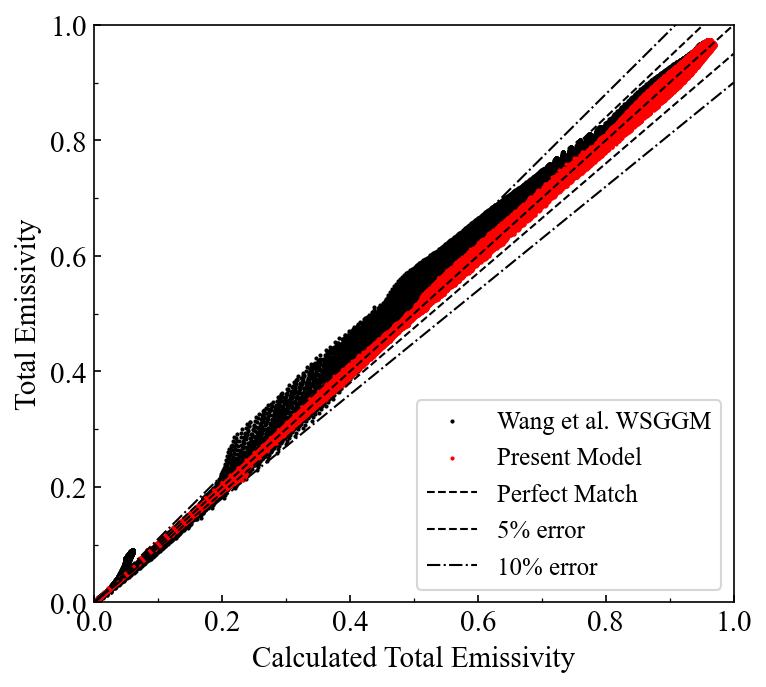

In [7]:
wang_epsilon_3d_est = calculate_wang_emissivity_3d(
    file_path="../input/coefficients_from_wang.xlsx",
    sheet_name="Px=0.2bar",
    mole_fraction_ratios=mole_fraction_ratios,
    temperatures=temperatures,
    path_lengths=path_lengths,
    Pt=Pt
)

# 创建图形和轴
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=150)

# 绘制散点图
plt.scatter(wang_epsilon_3d_est.flatten(), epsilon_3d.flatten(), c="black", s=1, label="Wang et al. WSGGM")
plt.scatter(epsilon_pred.flatten(), epsilon_3d.flatten(), c="red", s=1, label="Present Model")

# 绘制参考线
x_ref = np.linspace(0, 1, 100)
plt.plot(x_ref, x_ref, 'k--', linewidth=1.0, label='Perfect Match')
plt.plot(x_ref, x_ref*1.05, 'k--', linewidth=1.0, alpha=1.0, label='5% error')
plt.plot(x_ref, x_ref*0.95, 'k--', linewidth=1.0, alpha=1.0)
plt.plot(x_ref, x_ref*1.10, 'k-.', linewidth=1.0, alpha=1.0, label='10% error')
plt.plot(x_ref, x_ref*0.90, 'k-.', linewidth=1.0, alpha=1.0)

# 设置坐标轴
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Calculated Total Emissivity (Models)')
plt.ylabel('Total Emissivity (LBL)')

# 设置刻度线向内，并添加次要刻度
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='both', direction='in')

# 设置标签和图例
plt.legend(loc='lower right', prop={'size': 12})
plt.xlabel('Calculated Total Emissivity')
plt.ylabel('Total Emissivity')

# 保存图片
plt.savefig('../results/img/emissivity_plot_vs_wang.png', bbox_inches='tight')

# 显示图形
plt.show()

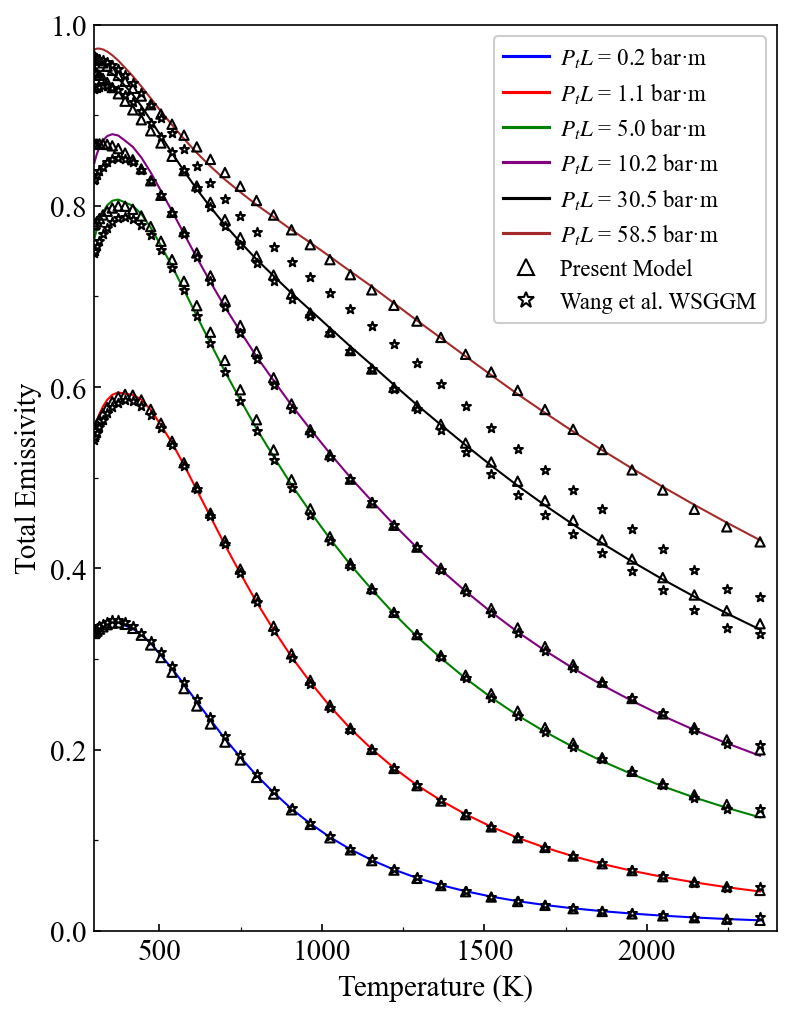

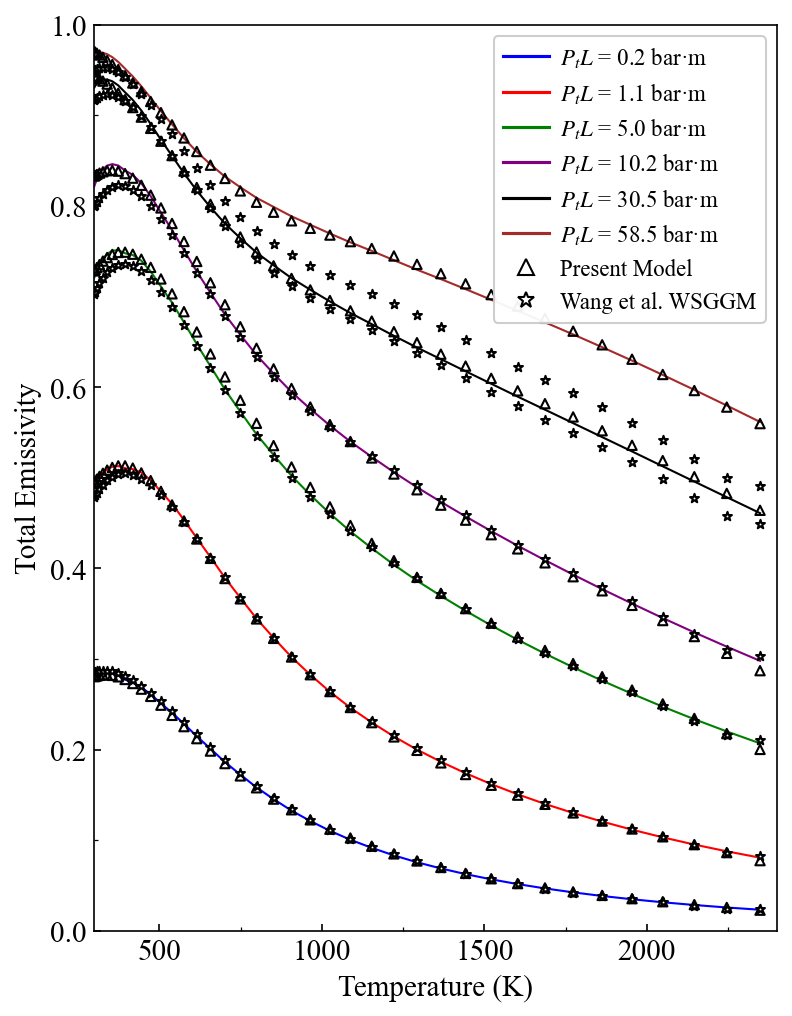

In [8]:
# 正确方式应分别排序温度和路径长度
sorted_temp_indices = np.argsort(temperatures)
temperatures_sorted = temperatures[sorted_temp_indices]  # 温度排序

sorted_path_indices = np.argsort(path_lengths)
path_lengths_sorted = path_lengths[sorted_path_indices]  # 路径长度排序
# 定义最近邻查找函数
def safe_find_closest(array, target):
    """改进版索引查找，支持未排序数组和边界检查"""
    if len(array) == 0:
        raise ValueError("输入数组不能为空")
    idx = np.nanargmin(np.abs(array - target))
    return max(0, min(idx, len(array)-1))

# 获取三个路径长度的索引
selected_path_lengths = [0.2, 1.0, 5.0, 10.0, 30.0, 60.0]
selected_path_indices = [safe_find_closest(path_lengths_sorted, pl) for pl in selected_path_lengths]
selected_mole_fraction_ratios = [0.5, 3]
selected_mr_indices = [safe_find_closest(mole_fraction_ratios, Mr) for Mr in selected_mole_fraction_ratios]

# 对每个摩尔分数比单独绘图
for mr_val, mr_idx in zip(selected_mole_fraction_ratios, selected_mr_indices):
    fig, ax = plt.subplots(figsize=(5.5, 7), dpi=150)
    
    # 定义颜色和样式
    colors = ['blue', 'red', 'green', 'purple', 'black','brown']  # 每个路径长度对应一种颜色
    markers = ['^', '*']  # 模型标记样式

    for i, path_idx in enumerate(selected_path_indices):
        path_val = path_lengths_sorted[path_idx]
        
        # 获取所有温度的数据
        lbl_data = epsilon_3d[mr_idx, sorted_temp_indices, path_idx]
        rsm_data = epsilon_pred[mr_idx, sorted_temp_indices, path_idx]
        wang_data = wang_epsilon_3d_est[mr_idx, sorted_temp_indices, path_idx]

        # 绘制LBL曲线
        ax.plot(temperatures_sorted, lbl_data,
                color=colors[i],
                linestyle='-',
                linewidth=1.0,
                zorder=1)

        # 绘制Present模型散点（与LBL同色）
        # ax.scatter(temperatures_sorted, rsm_data,
        #            color=colors[i],
        #            marker=markers[0],
        #            s=20,
        #            edgecolor='white',
        #            linewidth=0.5,
        #            zorder=2)
        ax.scatter(temperatures_sorted, rsm_data,
                   color=colors[i],
                   marker=markers[0],
                   s=20,
                   facecolors='none',
                   edgecolor='k',
                   linewidth=1.0,
                   zorder=2,
                   label='_nolegend_')

        # 绘制Wang模型散点（白色填充）
        ax.scatter(temperatures_sorted, wang_data,
                   color=colors[i],
                   marker=markers[1],
                   s=20,
                   edgecolor='k',
                   facecolor='white',
                   linewidth=1.0,
                   zorder=2)

    # 坐标轴设置
    # ax.set_xlim(temperatures.min(), temperatures.max())
    ax.set_ylim(0, 1)
    ax.set_xlim(300, 2400)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Total Emissivity')

    # 创建组合图例
    legend_elements = [
        # 路径长度图例（颜色+线型）
        *[Line2D([0], [0], color=colors[i], lw=1.5,
               label=f'$P_tL$ = {path_lengths_sorted[idx]:.1f} bar·m') 
         for i, idx in enumerate(selected_path_indices)],
        
        # 模型图例（标记样式）
        Line2D([0], [0], marker=markers[0], color='k', linestyle='None',
               markerfacecolor='w', markersize=8, label='Present Model'),
        Line2D([0], [0], marker=markers[1], color='k', linestyle='None',
               markerfacecolor='w', markeredgecolor='k', markersize=8, label='Wang et al. WSGGM')
    ]

    ax.legend(handles=legend_elements, 
             loc='upper right',
             fontsize=11,
             framealpha=0.95,
             handletextpad=0.5)

    plt.tight_layout()
    plt.savefig(f'../results/img/emissivity_pathlength_comparison_mr_{mr_val:.3f}_path_{path_val}.png', bbox_inches='tight')

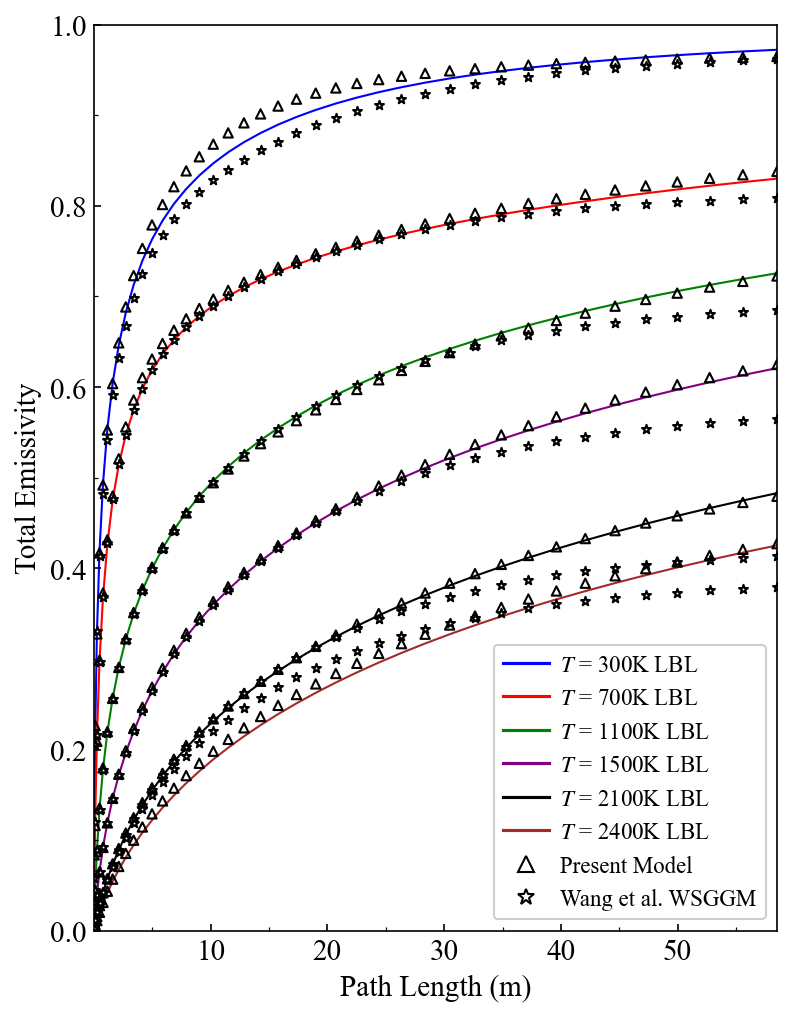

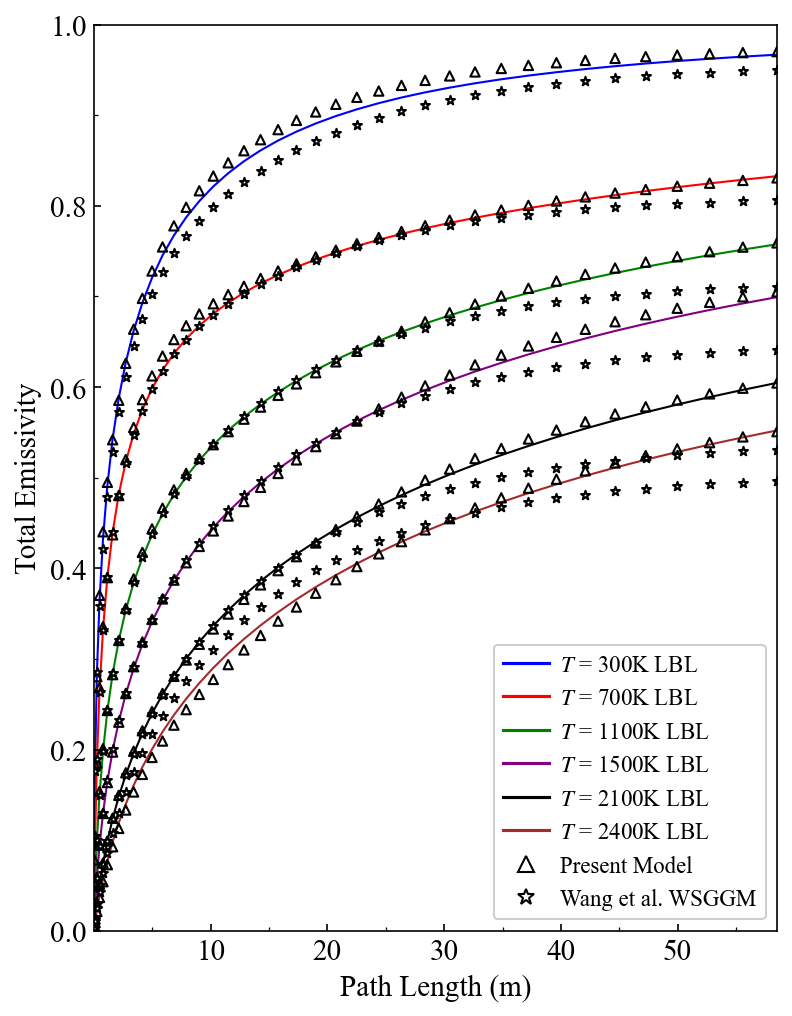

In [9]:
# 计算辐射率
mole_fraction_ratios, temperatures, _, epsilon_3d_validation = rsm.load_and_process_emissivity_data('../input/MixEmiss_p1.0_X0.2_Mr0.1-4.0_15_T22_path40.npy')
# 生成路径长度的排序索引和排序后的路径长度数组
sorted_path_indices = np.argsort(path_lengths)
path_lengths_sorted = path_lengths[sorted_path_indices]
# 重新生成发射率数据（只需运行一次）
selected_temperatures = [300, 700, 1100, 1500, 2100, 2400]  # 明确定义目标温度
selected_temp_indices = [np.where(temperatures == val)[0][0] for val in selected_temperatures]
selected_mole_fraction_ratios = [0.5, 3.0]
selected_mr_indices = [np.where(mole_fraction_ratios == val)[0][0] for val in selected_mole_fraction_ratios]
# 重新计算Wang模型数据（使用新温度数组）
wang_epsilon_3d_validation = calculate_wang_emissivity_3d(
    file_path="../input/coefficients_from_wang.xlsx",
    sheet_name="Px=0.2bar",
    mole_fraction_ratios= mole_fraction_ratios,
    temperatures=temperatures,  # 使用指定温度
    path_lengths=path_lengths,
    Pt=Pt
)

# 重新计算RSM模型数据（使用新温度数组）
rsm_epsilon_3d_validation = calculate_rsm_emissivity_3d(
    mole_fraction_ratios= mole_fraction_ratios,
    temperatures=temperatures,  # 使用指定温度
    path_lengths=path_lengths,
    Pt=Pt,
    X=X,
    T_ref=T_ref,
    Ng=Ng,
    Exp=Exp,
    beta=beta,
    gamma=gamma
)

# 对每个摩尔分数比单独绘图
for mr_val, mr_idx in zip(selected_mole_fraction_ratios, selected_mr_indices):
    # 创建图形
    fig, ax = plt.subplots(figsize=(5.5, 7), dpi=150)
    
    # 定义颜色和样式
    colors = ['blue', 'red', 'green', 'purple', 'black', 'brown']  # 每个温度对应一种颜色

    for i, temp_idx in enumerate(selected_temp_indices):
        temp_val = temperatures[temp_idx]  # 获取实际温度值
        
        # 按排序后的路径长度获取数据（使用正确的索引）
        lbl_data = epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]
        rsm_data = rsm_epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]
        wang_data = wang_epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]

        # 绘制LBL曲线
        ax.plot(path_lengths_sorted, lbl_data,
                color=colors[i], 
                linestyle='-',
                linewidth=1.0,
                zorder=1)
        
        # 绘制Present模型散点
        ax.scatter(path_lengths_sorted, rsm_data,
                   color=colors[i],
                   marker='^',
                   s=20,
                   edgecolor='k',
                   facecolors='none',
                   linewidth=1.0,
                   zorder=2,
                   label='_nolegend_')
        
        # 绘制Wang模型散点
        ax.scatter(path_lengths_sorted, wang_data,
                   color=colors[i],
                   marker='*',
                   s=20,
                   edgecolor='k',
                   facecolors='w',
                   linewidth=1.0,
                   zorder=2,
                   label='_nolegend_')

    # 坐标轴设置（保持不变）
    ax.set_xlim(path_lengths_sorted[0], path_lengths_sorted[-1])
    ax.set_ylim(0, 1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_xlabel('Path Length (m)')
    ax.set_ylabel('Total Emissivity')

    # 创建自定义图例
    legend_elements = [
        *[Line2D([0], [0], color=colors[i], lw=1.5, 
               label=f'$T$ = {temp}K LBL') 
         for i, temp in enumerate(selected_temperatures)],
        Line2D([0], [0], marker='^', color='k', linestyle='None',
               markerfacecolor='w', markeredgecolor='k', markersize=8,
               label='Present Model'),
        Line2D([0], [0], marker='*', color='k', linestyle='None',
               markerfacecolor='w', markeredgecolor='k', markersize=8,
               label='Wang et al. WSGGM')
    ]
    ax.legend(handles=legend_elements, 
             loc='lower right',
             fontsize=11,
             framealpha=0.95,
             handletextpad=0.5)

    plt.tight_layout()
    # 使用实际摩尔分数比值格式化文件名
    plt.savefig(f'../results/img/emissivity_temperature_comparison_mr_{mr_val:.3f}.png', bbox_inches='tight')

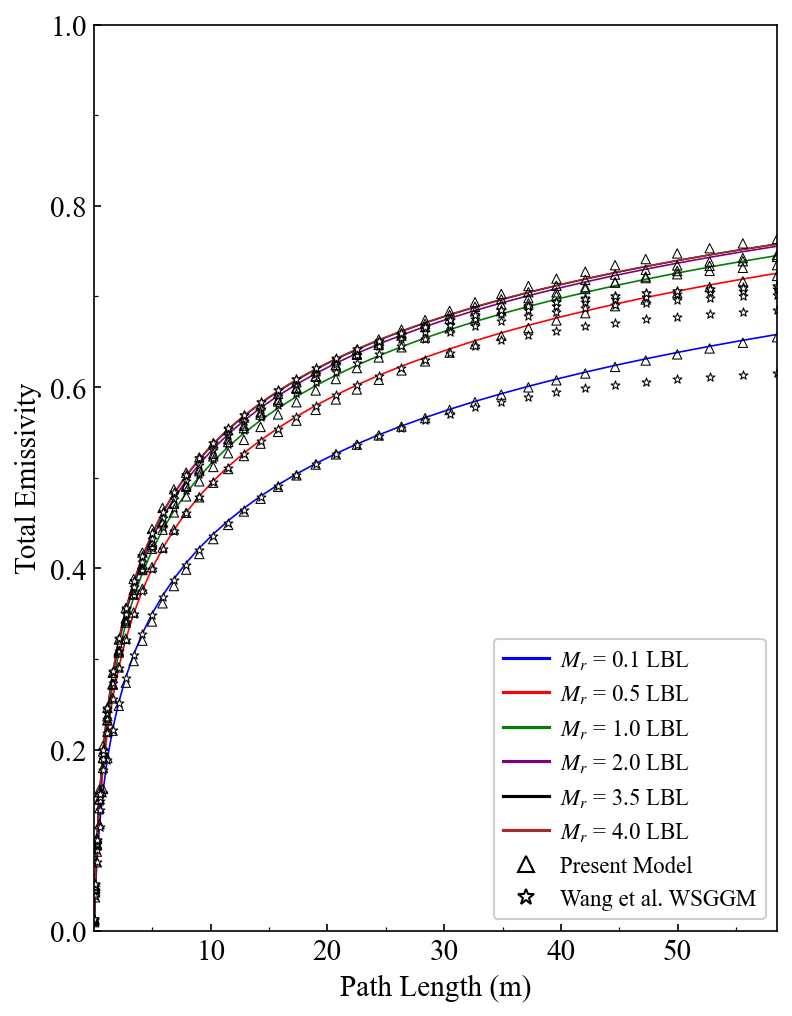

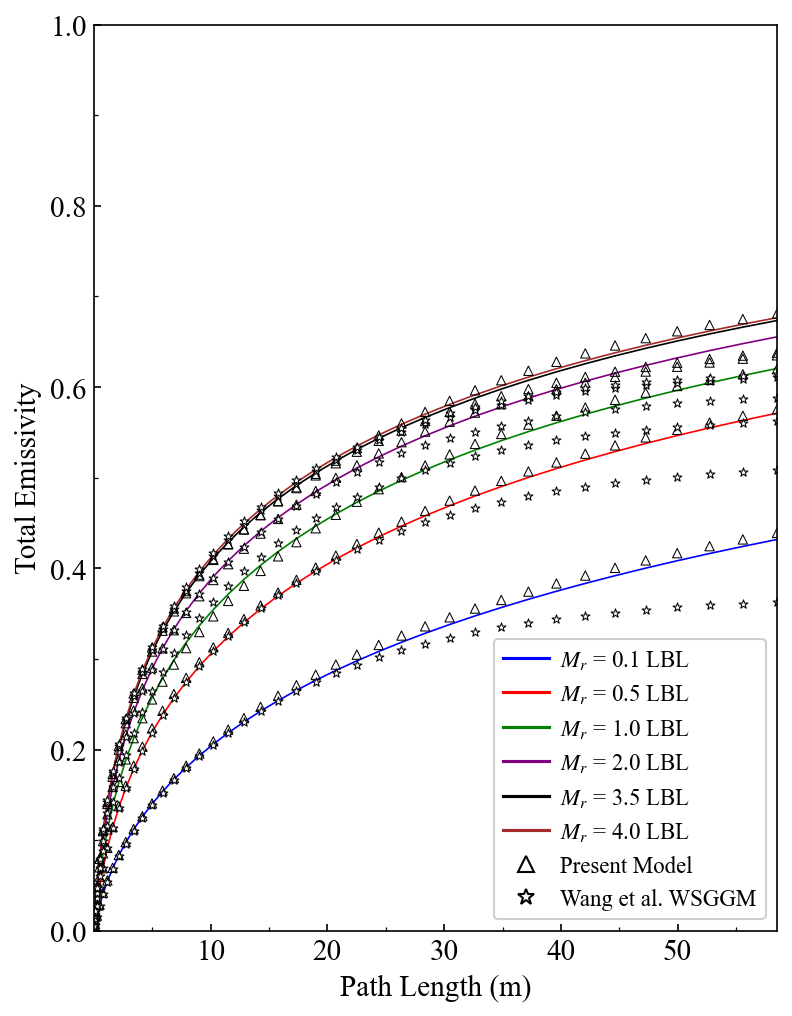

In [10]:
from matplotlib.lines import Line2D

# 计算辐射率
mole_fraction_ratios, temperatures, _, epsilon_3d_validation = rsm.load_and_process_emissivity_data('../input/MixEmiss_p1.0_X0.2_Mr0.1-4.0_15_T22_path40.npy')
# 生成路径长度的排序索引和排序后的路径长度数组
sorted_path_indices = np.argsort(path_lengths)
path_lengths_sorted = path_lengths[sorted_path_indices]
# 重新生成发射率数据（只需运行一次）
selected_temperatures = [1100, 1700]  # 明确定义目标温度
selected_temp_indices = [np.where(temperatures == val)[0][0] for val in selected_temperatures]
selected_mole_fraction_ratios = [0.1, 0.5, 1.0, 2.0, 3.5, 4.0]
selected_mr_indices = [np.where(mole_fraction_ratios == val)[0][0] for val in selected_mole_fraction_ratios]
# 重新计算Wang模型数据（使用新温度数组）
wang_epsilon_3d_validation = calculate_wang_emissivity_3d(
    file_path="../input/coefficients_from_wang.xlsx",
    sheet_name="Px=0.2bar",
    mole_fraction_ratios= mole_fraction_ratios,
    temperatures=temperatures,  # 使用指定温度
    path_lengths=path_lengths,
    Pt=Pt
)

# 重新计算RSM模型数据（使用新温度数组）
rsm_epsilon_3d_validation = calculate_rsm_emissivity_3d(
    mole_fraction_ratios= mole_fraction_ratios,
    temperatures=temperatures,  # 使用指定温度
    path_lengths=path_lengths,
    Pt=Pt,
    X=X,
    T_ref=T_ref,
    Ng=Ng,
    Exp=Exp,
    beta=beta,
    gamma=gamma
)

# 定义颜色和样式
colors = ['blue', 'red', 'green', 'purple', 'black', 'brown']  # 每个摩尔比对应一种颜色
markers = ['^', '*']               # Present和Wang模型的标记

# 对每个温度单独绘图
for temp_idx in selected_temp_indices:
    temp_val = temperatures[temp_idx]  # 获取实际温度值
    fig, ax = plt.subplots(figsize=(5.5, 7), dpi=150)

    for i, (mr_val, mr_idx) in enumerate(zip(selected_mole_fraction_ratios, selected_mr_indices)):
       # 按排序后的路径长度获取数据（使用正确的索引）
        lbl_data = epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]
        rsm_data = rsm_epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]
        wang_data = wang_epsilon_3d_validation[mr_idx, temp_idx, :][sorted_path_indices]
        
        # 绘制LBL曲线
        ax.plot(path_lengths_sorted, lbl_data,
                color=colors[i], 
                linestyle='-',
                linewidth=0.8,
                zorder=1)
        
        # 绘制Present模型散点
        ax.scatter(path_lengths_sorted, rsm_data,
                   color=colors[i],
                   marker=markers[0],
                   s=20,
                   facecolors='none',
                   edgecolor='k',
                   linewidth=0.5,
                   zorder=2,
                   label='_nolegend_')
        
        # 绘制Wang模型散点
        ax.scatter(path_lengths_sorted, wang_data,
                   color=colors[i],
                   marker=markers[1],
                   s=20,
                   facecolor='w',
                   edgecolor='k',
                   linewidth=0.5,
                   zorder=2,
                   label='_nolegend_')

    # 坐标轴设置（保持不变）
    ax.set_xlim(path_lengths_sorted[0], path_lengths_sorted[-1])
    ax.set_ylim(0, 1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_xlabel('Path Length (m)')
    ax.set_ylabel('Total Emissivity')

    # 创建自定义图例
    legend_elements = [
        Line2D([0], [0], color=color, lw=1.5, label=f'$M_r$ = {mr_val} LBL') 
        for mr_val, color in zip(selected_mole_fraction_ratios, colors)
    ] + [
        Line2D([0], [0], marker=markers[0], color='k', linestyle='None', markerfacecolor='w', markeredgecolor='k', markersize=8, label='Present Model'),
        Line2D([0], [0], marker=markers[1], color='k', linestyle='None', markerfacecolor='w', markeredgecolor='k', markersize=8, label='Wang et al. WSGGM')
    ]
    
    ax.legend(handles=legend_elements, 
             loc='lower right',
             fontsize=11,
             framealpha=0.95,
             handletextpad=0.5)

    plt.tight_layout()
    # 使用实际摩尔分数比值格式化文件名
    plt.savefig(f'../results/img/emissivity_mr_comparison_{temp_val}K.png', bbox_inches='tight')

# 验证 RSM_WSGG 一维辐射换热求解精度

```python
"""
RSM_WSGG 模型一维辐射换热验证案例
验证方法：与 LBL 解对比计算误差
参考文献：Modest M. Radiative Heat Transfer. 2022. Chapter 20.4
"""

In [11]:
# 生成profile文件，计算LBL的解析解并保存在 resluts文件夹，仅在修改profile的情况下需要运行一次本模块
from src.profile_generator import generate_profiles, CASE_CONFIGS
# 左右边界温度
T_l = T_r = 300.0

# 生成测试 Case的profile
# SELECTED_CASES = ["1.1", "1.2", "1.3", "2.1", "2.2", "3.1", "3.2"]
# generate_profiles(
#     case_configs=CASE_CONFIGS,
#     l_values=[1.0],
#     n_points=100,
#     output_dir="../input/profiles",
#     selected_cases=SELECTED_CASES
# )
# solver.getLBLsolution(T_l, T_r, Pt)

In [12]:
# # 绘制profile图
# # 定义案例顺序（两行三列）
# case_order = [
#     'Case1.1_L1.0m', 'Case1.2_L1.0m', 'Case1.3_L1.0m',
#     'Case2.1_L1.0m', 'Case2.2_L1.0m', 'Case3.1_L1.0m', 'Case3.2_L1.0m'
# ]

# # 定义统一的样式配置
# species_styles = {
#     'T':    {'color': 'crimson', 'ls': '-',  'label': 'Temperature'},
#     'H2O':  {'color': 'limegreen', 'ls': '--', 'label': 'H$_2$O'},
#     'NH3':  {'color': 'dodgerblue', 'ls': ':',  'label': 'NH$_3$'}
# }

# # 创建带子图的画布
# fig, axs = plt.subplots(2, 3, figsize=(15, 8), dpi=100)
# plt.subplots_adjust(wspace=0.1, hspace=0.1)  # 调整子图间距

# # 遍历每个案例绘制子图
# for idx, case_prefix in enumerate(case_order):
#     row = idx // 3  # 计算行号
#     col = idx % 3   # 计算列号
    
#     # 初始化双轴
#     ax1 = axs[row, col]
#     ax2 = ax1.twinx()
    
#     # 加载数据
#     case_files = glob.glob(f"profiles/{case_prefix}*.npy")
#     if not case_files:
#         print(f"文件未找到: {case_prefix}")
#         continue
    
#     profile = np.load(case_files[0], allow_pickle=False)
#     x = profile['x']
#     case_id = case_prefix.split('_')[0]  # 提取案例号如 "Case1"
    
#     # ---------------------------
#     # 核心修改：将案例号添加至右上角
#     # ---------------------------
#     ax1.text(
#         0.95, 0.95,  # 右上角坐标 (相对位置，1为轴的最大范围)
#         case_id, 
#         transform=ax1.transAxes,  # 使用相对坐标系
#         ha='right',   # 水平对齐：右
#         va='top',     # 垂直对齐：顶
#         fontsize=12,
#         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')  # 白色背景提高可读性
#     )
    
#     # 绘制三条曲线
#     l1, = ax1.plot(x, profile['T'], 
#                   color=species_styles['T']['color'], linewidth=2, 
#                   linestyle=species_styles['T']['ls'])
    
#     l2, = ax2.plot(x, profile['Y_H2O'],
#                   color=species_styles['H2O']['color'],linewidth=2, 
#                   linestyle=species_styles['H2O']['ls'])
    
#     l3, = ax2.plot(x, profile['Y_NH3'],
#                   color=species_styles['NH3']['color'],linewidth=2, 
#                   linestyle=species_styles['NH3']['ls'])
    
#     # 统一坐标范围
#     ax1.set_xlim(0, x.max())
#     ax1.set_ylim(300, 2000)
#     ax2.set_ylim(0, 1.0)
    
#     # 坐标轴标签设置（仅在边缘显示）
#     if row == 1:  # 最后一行显示x轴标签
#         ax1.set_xlabel('x/L', fontsize=12)
#     if col == 0:  # 第一列显示左轴标签
#         ax1.set_ylabel('Temperature (K)', fontsize=12)
#     if col == 2:  # 最后一列显示右轴标签
#         ax2.set_ylabel('Molar Fraction (-)', fontsize=12)
    
#     # 统一刻度样式
#     ax1.tick_params(axis='both', labelsize=12, direction='in', which='both')
#     ax2.tick_params(axis='y', labelsize=12, direction='in', which='both')
#     ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
#     ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
#     ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

# # 添加全局图例
# fig.legend([l1, l2, l3],
#            [species_styles['T']['label'],
#             species_styles['H2O']['label'],
#             species_styles['NH3']['label']],
#            loc='upper center',     # 锚点设置为图例顶部居中
#            bbox_to_anchor=(0.5, 1.05),  # 将图例向上偏移至图外
#            ncol=3,
#            fontsize=12,
#            frameon=False)

# # 调整布局并保存
# plt.tight_layout()
# save_path = os.path.join('./img', 'all_cases_comparison.png')
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
# plt.show()

In [13]:
# # 定义需要组合的工况组
# case_groups = [
#     ('Case1_L1.0m', 'Case2_L1.0m'),
#     ('Case3_L1.0m', 'Case4_L1.0m'),
#     ('Case5_L1.0m', 'Case6_L1.0m')
# ]

# # 定义颜色方案
# colors = {
#     'T':  ['crimson', 'darkred'],
#     'H2O': ['limegreen', 'darkgreen'],
#     'NH3': ['dodgerblue', 'navy']
# }

# # 遍历每个工况组
# for group in case_groups:
#     fig, ax1 = plt.subplots()
#     ax2 = ax1.twinx()
    
#     # 判断是否需要合并温度曲线（Case3/Case4 或 Case5/Case6）
#     group_case_ids = {case.split("_")[0] for case in group}
#     merge_temp = group_case_ids in [{'Case3', 'Case4'}, {'Case5', 'Case6'}]
    
#     # 遍历组内的每个工况
#     for i, case_prefix in enumerate(group):
#         # 查找匹配文件
#         case_files = glob.glob(f"profiles/{case_prefix}*.npy")
#         case_id, L_tag = case_prefix.split("_")  # 示例: "Case1_L0.1m" → case_id="Case1", L_tag="L0.1m"
#         if not case_files:
#             print(f"未找到文件: profiles/{case_prefix}*.npy")
#             continue
            
#         # 加载数据（取第一个匹配文件）
#         profile = np.load(case_files[0], allow_pickle=False)
        
#         # 提取参数
#         x = profile['x']
#         temperature = profile['T']
#         h2o = profile['Y_H2O']
#         nh3 = profile['Y_NH3']
        
#         # ========== 温度曲线逻辑修改 ==========
#         if merge_temp:
#             # 合并温度曲线（只在第一个case绘制）
#             if i == 0:
#                 ax1.plot(x, temperature, 
#                         color=colors['T'][i], 
#                         linestyle='-',
#                         linewidth=2,
#                         label='Temperature')  # 统一标签
#         else:
#             # 正常绘制温度曲线
#             ax1.plot(x, temperature, 
#                     color=colors['T'][i], 
#                     linestyle='-',
#                     linewidth=2,
#                     label=f'{case_id} Temperature')  # 原始标签
        
#         # ========== 物种曲线保持不变 ==========
#         ax2.plot(x, h2o, 
#                 color=colors['H2O'][i],
#                 linestyle='--',
#                 linewidth=1.5,
#                 label=f'{case_id} H$_2$O')
        
#         ax2.plot(x, nh3,
#                 color=colors['NH3'][i],
#                 linestyle=':',
#                 linewidth=1.5,
#                 label=f'{case_id} NH$_3$')
    
#     # 设置坐标轴属性（保持不变）
#     ax1.set_xlabel('x/L', fontsize=12)
#     ax1.set_ylabel('Temperature (K)', color='black', fontsize=12)
#     ax2.set_ylabel('Molar Fraction (-)', color='black', fontsize=12)
    
#     # ========== 图例配置（保持不变）==========
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
    
#     # 创建组合图例
#     legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=3)
    
#     # 设置图例透明度
#     legend.get_frame().set_alpha(0.9)
    
#     # 调整布局边距
#     plt.subplots_adjust(top=0.82)  # 根据图例高度调整
    
#     # 设置坐标范围
#     ax1.set_xlim(0, x.max())
#     ax1.set_ylim(300, 2100)  # 根据实际情况调整
#     ax2.set_ylim(0, 1.0)
#     ax1.tick_params(axis='both', direction='in', which='both')
#     ax2.tick_params(axis='y', direction='in', which='both')
#     ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
#     ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
#     ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
    
#     # 调整布局并保存
#     plt.tight_layout()
#     # save_path = os.path.join('./img', f"Comparison_{group[0]}_vs_{group[1]}.png")  # 修改路径
#     plt.savefig(f"./img/Comparison_{group[0]}_vs_{group[1]}.png", 
#                dpi=300, 
#                bbox_inches='tight')  # 自动调整边
#     plt.show()

In [14]:
def wsgg_rsm_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r):
    rsm_a, rsm_k = np.zeros([len(xs), Ng+1]), np.zeros([len(xs), Ng+1])
    for i in range(len(xs)):
        # t, x_h2o, x_nh3 = temperature_profiles[i], x_h2o_profiles[i] * 100.0, x_nh3_profiles[i] * 100.0
        t, x_h2o, x_nh3 = temperature_profiles[i], x_h2o_profiles[i], x_nh3_profiles[i]
        Tr = t / T_ref
        rsm_a[i, :], rsm_k[i, :] = rsm.get_k_a_ML(Tr, x_h2o/x_nh3, Ng, Exp, beta, gamma)
    rsm_k *= (x_h2o_profiles + x_nh3_profiles).reshape(-1, 1)
    rsm_dq = 0.0
    rsm_q = 0.0

    for i in range(Ng+1):
        a = rsm_a[:, i]
        k = rsm_k[:, i]
        i_b = Stefan_Boltzmann * (temperature_profiles ** 4) * a / np.pi
        i_b1 = Stefan_Boltzmann * (T_l ** 4) * a[0] / np.pi
        i_b2 = Stefan_Boltzmann * (T_r ** 4) * a[-1] / np.pi
        _, cur_q, cur_dq = solver.solve_rte(xs, k, i_b, i_b1, i_b2)
        rsm_dq += cur_dq
        rsm_q += cur_q
       
    return rsm_q, rsm_dq

In [15]:
def wsgg_wang_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r):
    coefficients, range_dict = wang.read_coefficients_with_ranges("../input/coefficients_from_wang.xlsx", sheet_name="Px=0.2bar")
    wang_a, wang_k = np.zeros([len(xs), 5]), np.zeros([len(xs), 5])
    for i in range(len(xs)):
        # t, x_h2o, x_nh3 = temperature_profiles[i], x_h2o_profiles[i] * 100.0, x_nh3_profiles[i] * 100.0
        t, x_h2o, x_nh3 = temperature_profiles[i], x_h2o_profiles[i], x_nh3_profiles[i]
        wang_a[i, :], wang_k[i, :] = wang.get_k_a(t, x_h2o/x_nh3, 4, coefficients, range_dict)
    # wang_k *= (x_h2o_profiles + x_nh3_profiles).reshape(-1, 1) / X
    
    wang_dq = 0.0
    wang_q = 0.0

    for i in range(5):
        a = wang_a[:, i]
        k = wang_k[:, i]
        i_b = Stefan_Boltzmann * (temperature_profiles ** 4) * a / np.pi
        i_b1 = Stefan_Boltzmann * (T_l ** 4) * a[0] / np.pi
        i_b2 = Stefan_Boltzmann * (T_r ** 4) * a[-1] / np.pi
        _, cur_q, cur_dq = solver.solve_rte(xs, k, i_b, i_b1, i_b2)
        wang_dq += cur_dq
        wang_q += cur_q

    return wang_q, wang_dq

In [16]:
# DATA_DIR = "profiles"
# RESULTS_DIR = "results"
# OUTPUT_DIR = "img"

# # 获取所有案例文件并分组
# case_files = glob.glob(os.path.join(DATA_DIR, "Case*.npy"))
# case_dict = {}  # {case_id: list of L values}

# for file_path in case_files:
#     filename = os.path.basename(file_path).replace(".npy", "")
#     case_id, L_tag = filename.split("_")
#     L = float(L_tag[1:-1])
#     if case_id not in case_dict:
#         case_dict[case_id] = []
#     case_dict[case_id].append(L)

# # 配置绘图参数
# plt.rcParams.update({
#     'font.size': 12,
#     'font.family': 'Arial',
#     'mathtext.fontset': 'stix'
# })

# # 定义所有可能的L值及颜色
# all_Ls = [1.0, 5.0]

# # 处理每个案例
# for case_id in case_dict:
#     fig, axs = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
#     data = {}  # {L: {flux, source, xs_norm}}
#     wsgg_data = {}  # {L: {flux, source, xs_norm}}

#     # 加载该案例的所有L值数据
#     for L in all_Ls:
#         try:
#             # 加载profile和results文件
#             profile = np.load(os.path.join(DATA_DIR, f"{case_id}_L{L}m.npy"))
#             results = np.load(os.path.join(RESULTS_DIR, f"{case_id}_L{L}m.npy")) / 1e3
            
#             # 提取参数 (结构化数组访问)
#             xs = profile['x']                # 空间坐标 [m]
#             temperature_profiles = profile['T']      # 温度 [K]
#             x_h2o_profiles = profile['Y_H2O']          # H2O摩尔分数
#             x_nh3_profiles = profile['Y_NH3'] + 1e-4          # NH3摩尔分数
#             # xss = np.vstack([x_h2o_profiles, x_nh3_profiles]).T
#             xs_norm = xs / L
            
#             data[L] = {
#                 'flux': -results[:, 1],
#                 'source': -results[:, -1],
#                 'xs_norm': xs_norm
#             }
        
#             q, dq = wsgg_bord_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r)
#             wsgg_q = q / 1e3  # 转换为 kW/m²
#             wsgg_dq = dq / 1e3  # 转换为 kW/m³
            
#             wsgg_data[L] = {
#                 'flux': -wsgg_q,
#                 'source': -wsgg_dq,
#                 'xs_norm': xs_norm
#             }
        
#         except FileNotFoundError:
#             print(f"Warning: Data for {case_id} L{L}m not found.")
#             continue

#     # 绘制每个L值的数据
#     for row_idx, L in enumerate(all_Ls):
#         if L not in data:
#             continue  # 跳过缺失数据
            
#         # 热通量 (左列)
#         axs[row_idx, 0].plot(
#             data[L]['xs_norm'], 
#             data[L]['flux'],
#             color='black',
#             label='LBL'
#         )
#         # 添加散点图 (wsgg_q)
#         axs[row_idx, 0].scatter(
#             wsgg_data[L]['xs_norm'],
#             wsgg_data[L]['flux'],  # 确保与 xs_norm 长度一致
#             color='black',
#             marker='o',
#             s=20,
#             label='RSM-WSGG Model'
#         )
        
#         # 源项 (右列)
#         axs[row_idx, 1].plot(
#             data[L]['xs_norm'],
#             data[L]['source'],
#             color='black',
#             label='LBL'
#         )
#         # 添加散点图 (wsgg_dq)
#         axs[row_idx, 1].scatter(
#             data[L]['xs_norm'],
#             wsgg_data[L]['source'],  # 确保与 xs_norm 长度一致
#             color='black',
#             marker='o',
#             s=10,
#             label='RSM-WSGG Model'
#         )
        
#         # 子图设置
#         for col in (0, 1):
#             ax = axs[row_idx, col]
#             ax.grid(linestyle=':', alpha=0.6)
#             ax.set_xlim(0, 1)
#             ax.set_title(f'L = {L} m', x=0.11, y=0.01)
#             ax.set_xlabel('')
#             # ax.set_ylim(-250, 50)
            
#         axs[row_idx, 0].set_ylabel('Heat Flux (kW/m²)', fontsize=12)
#         axs[row_idx, 1].set_ylabel('Source Term (kW/m³)', fontsize=12)
#         axs[row_idx, 1].yaxis.set_label_position("left")

#     plt.tight_layout()

#     handles, labels = axs[0, 0].get_legend_handles_labels()
#     fig.legend(
#         handles, labels,
#         loc='upper center',
#         bbox_to_anchor=(0.5, 1.02),
#         ncol=2,
#         fontsize=12,
#         frameon=False
#     )

#     # 设置公共标签
#     fig.supxlabel('Normalized Position (x/L)', ha='center', y=-0.01)  # 调整y值控制垂直位置
    
#     # 保存并关闭
#     os.makedirs(OUTPUT_DIR, exist_ok=True)
    
#     # plt.savefig(
#     #     f'{OUTPUT_DIR}/{case_id}_analysis.png',
#     #     bbox_inches='tight',  # 关键参数：包含所有画布内容
#     #     pad_inches=0.1,       # 添加额外边距
#     #     dpi=300
#     # )
#     plt.show()

# print("Processing completed.")

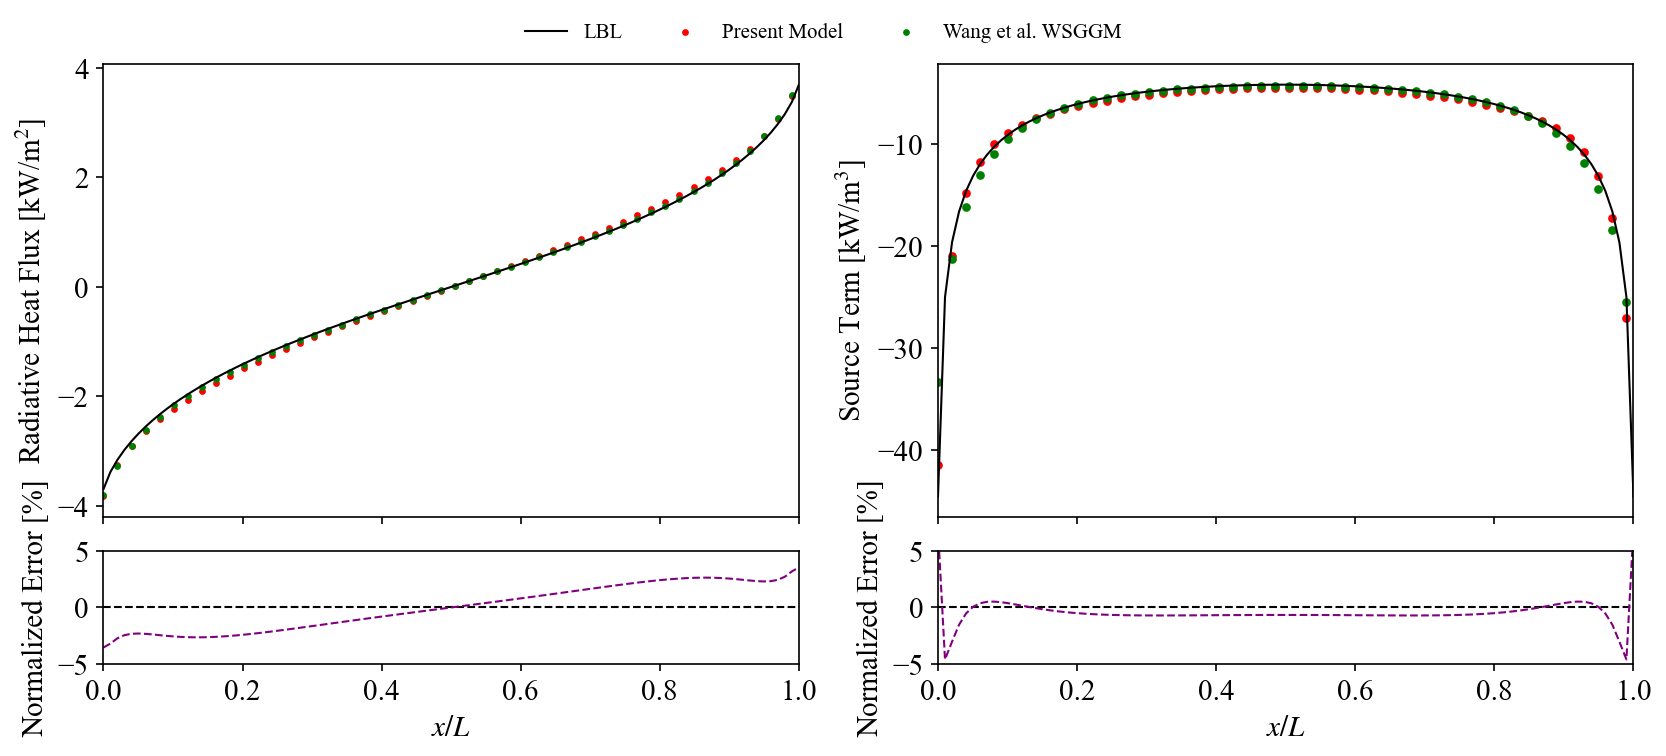

=== 工况 Case1.1_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 1.78%, 最大绝对误差: 3.54%
源项        - 平均绝对误差: 0.82%, 最大绝对误差: 6.88%
--------------------------------------------------


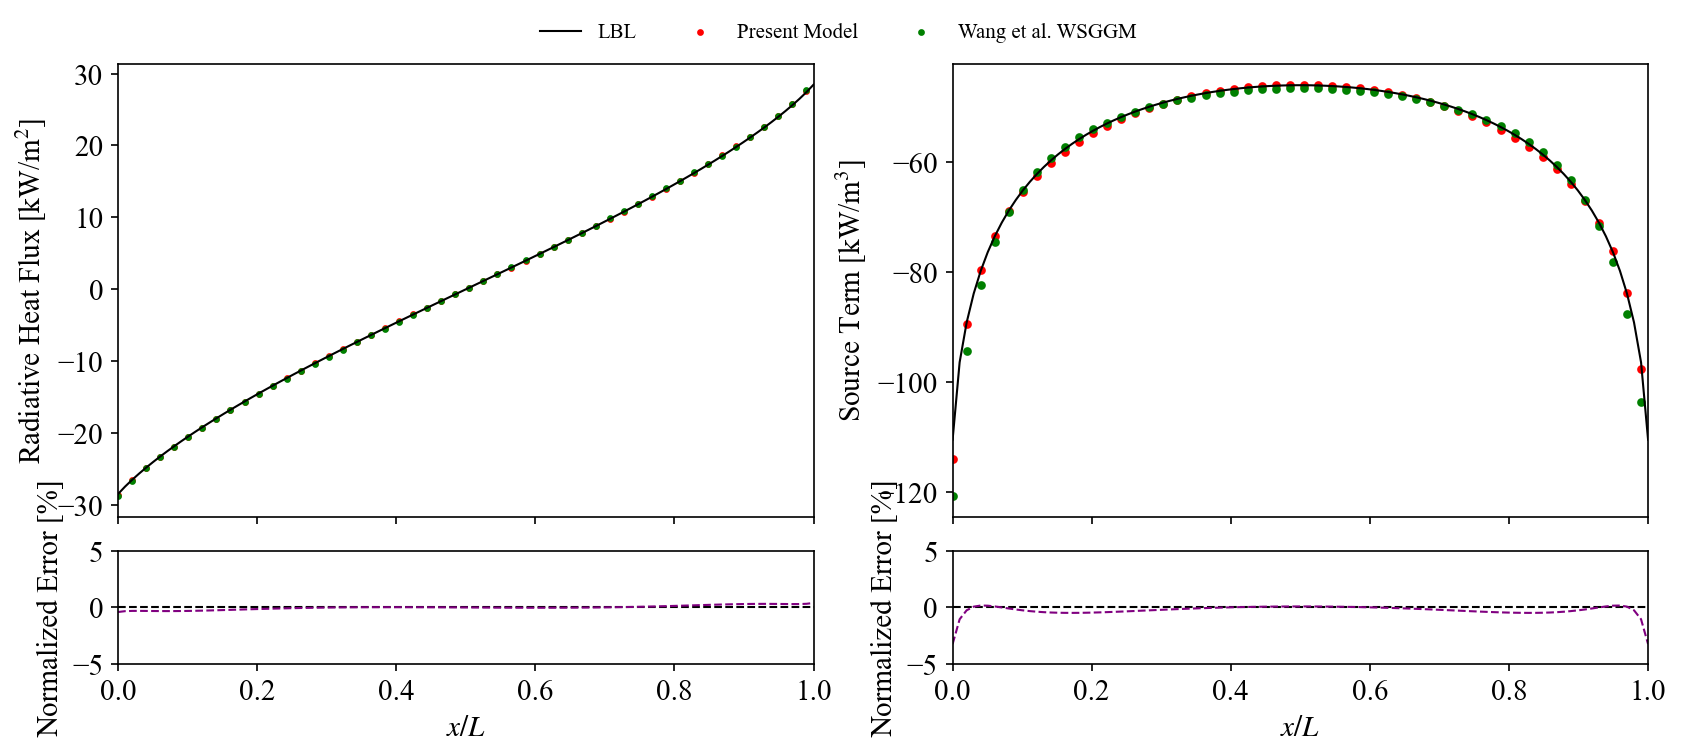

=== 工况 Case1.2_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 0.13%, 最大绝对误差: 0.40%
源项        - 平均绝对误差: 0.29%, 最大绝对误差: 3.23%
--------------------------------------------------


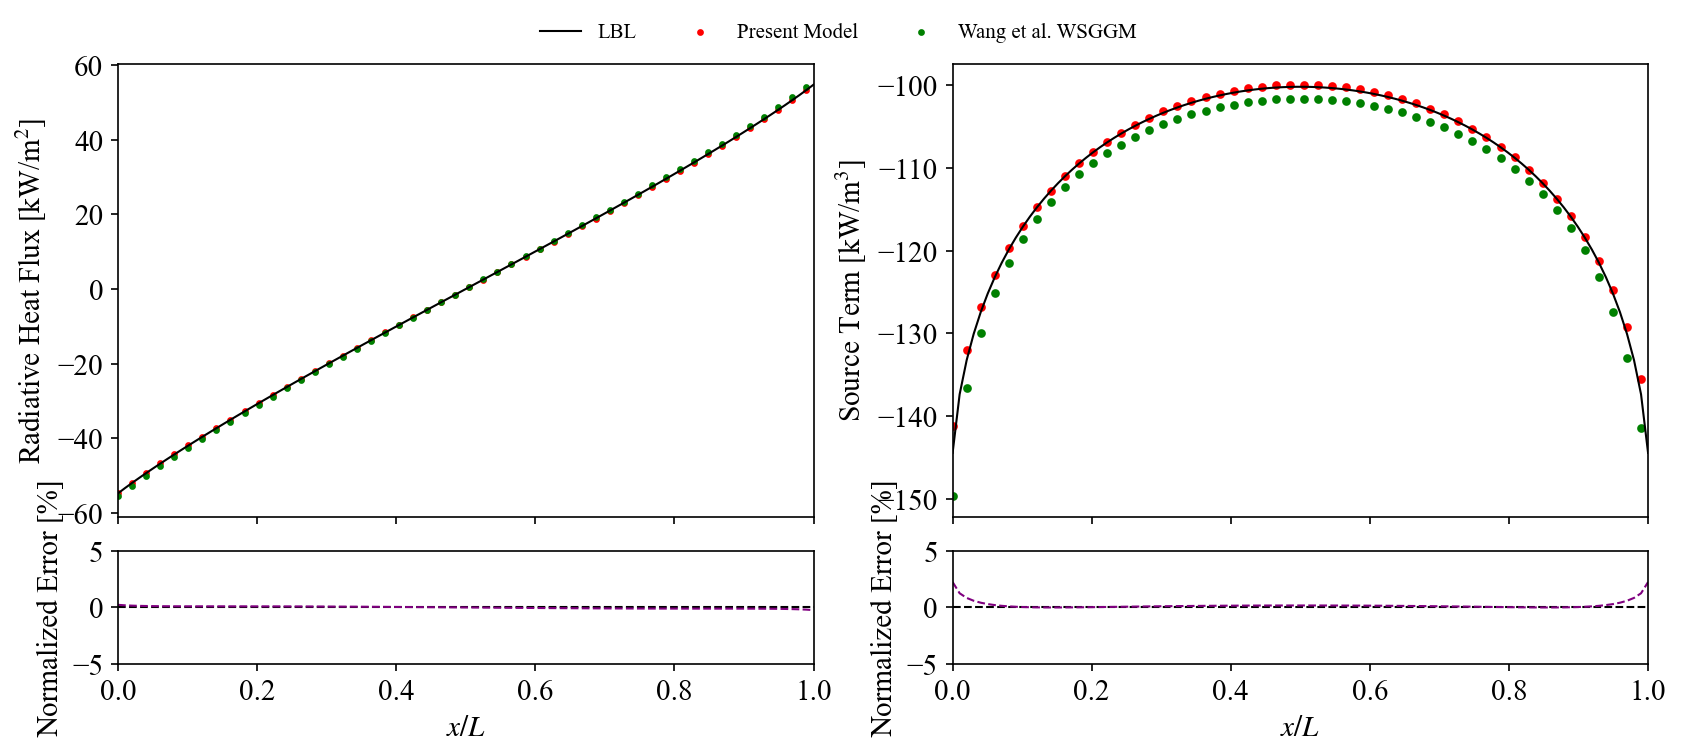

=== 工况 Case1.3_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 0.08%, 最大绝对误差: 0.23%
源项        - 平均绝对误差: 0.20%, 最大绝对误差: 2.25%
--------------------------------------------------


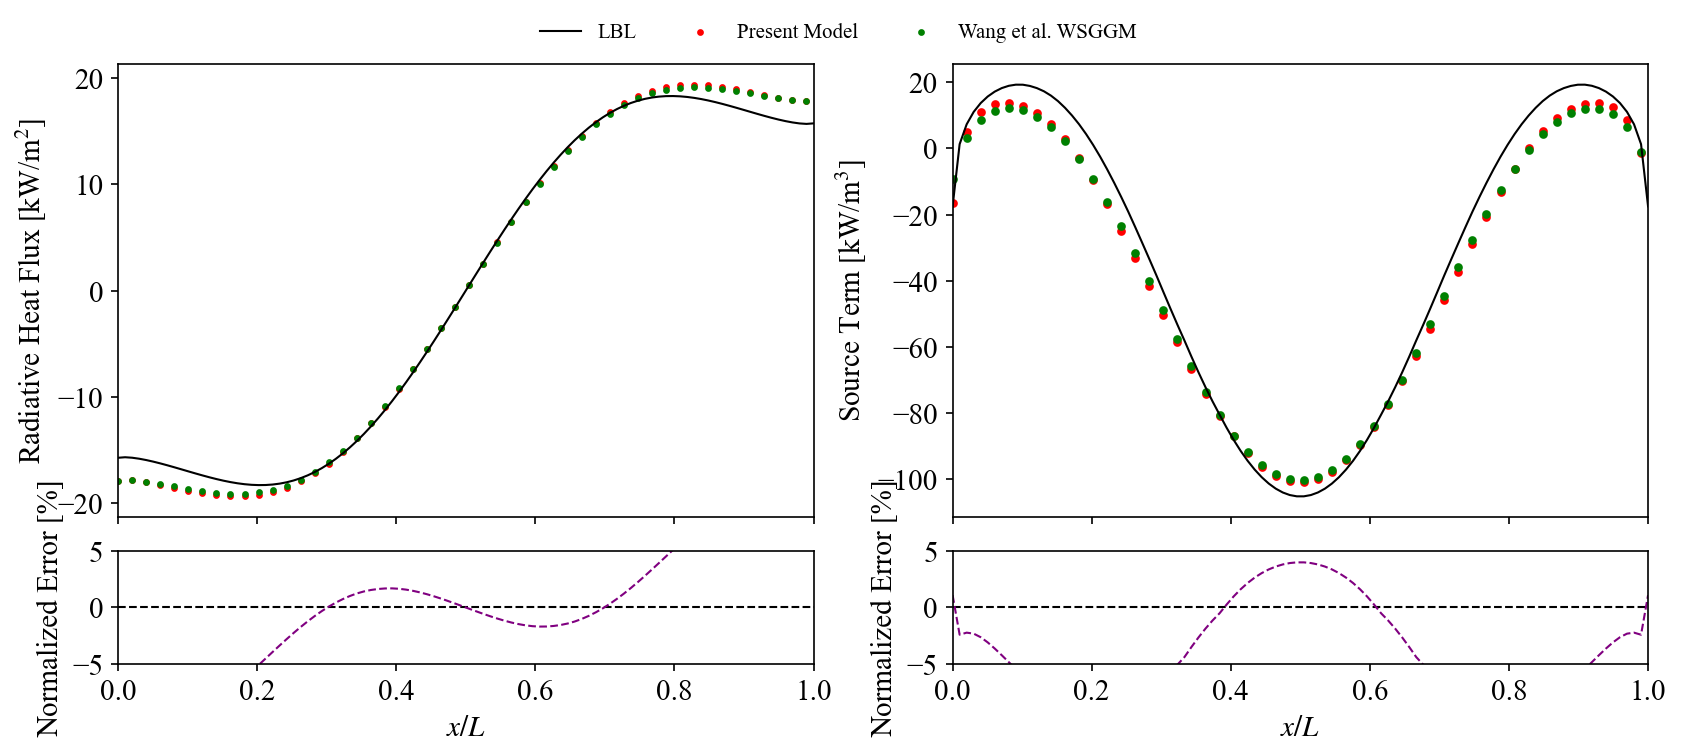

=== 工况 Case2.1_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 4.79%, 最大绝对误差: 11.95%
源项        - 平均绝对误差: 5.34%, 最大绝对误差: 10.10%
--------------------------------------------------


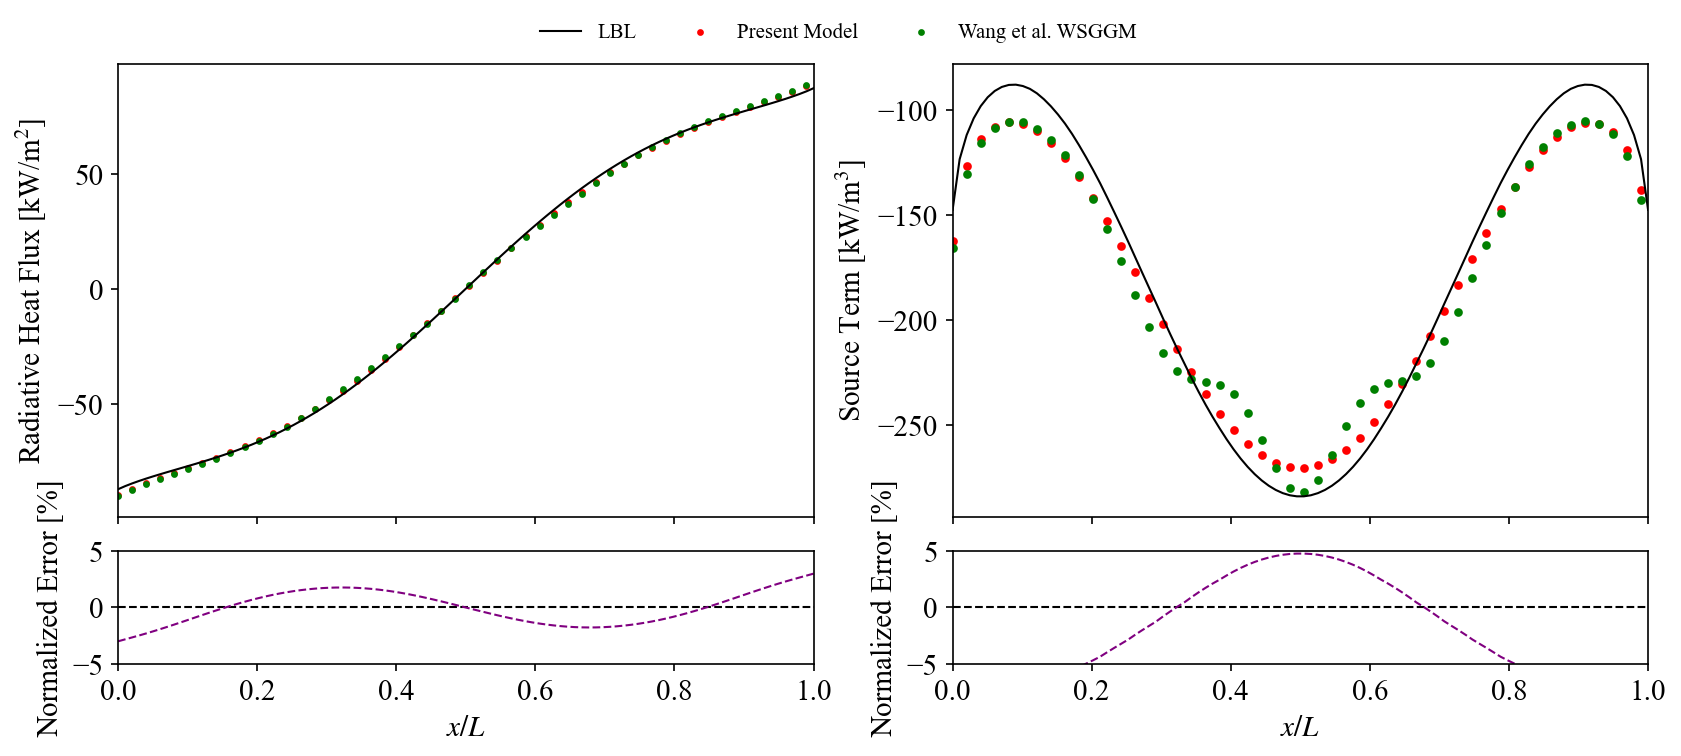

=== 工况 Case2.2_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 1.28%, 最大绝对误差: 2.99%
源项        - 平均绝对误差: 4.02%, 最大绝对误差: 6.46%
--------------------------------------------------


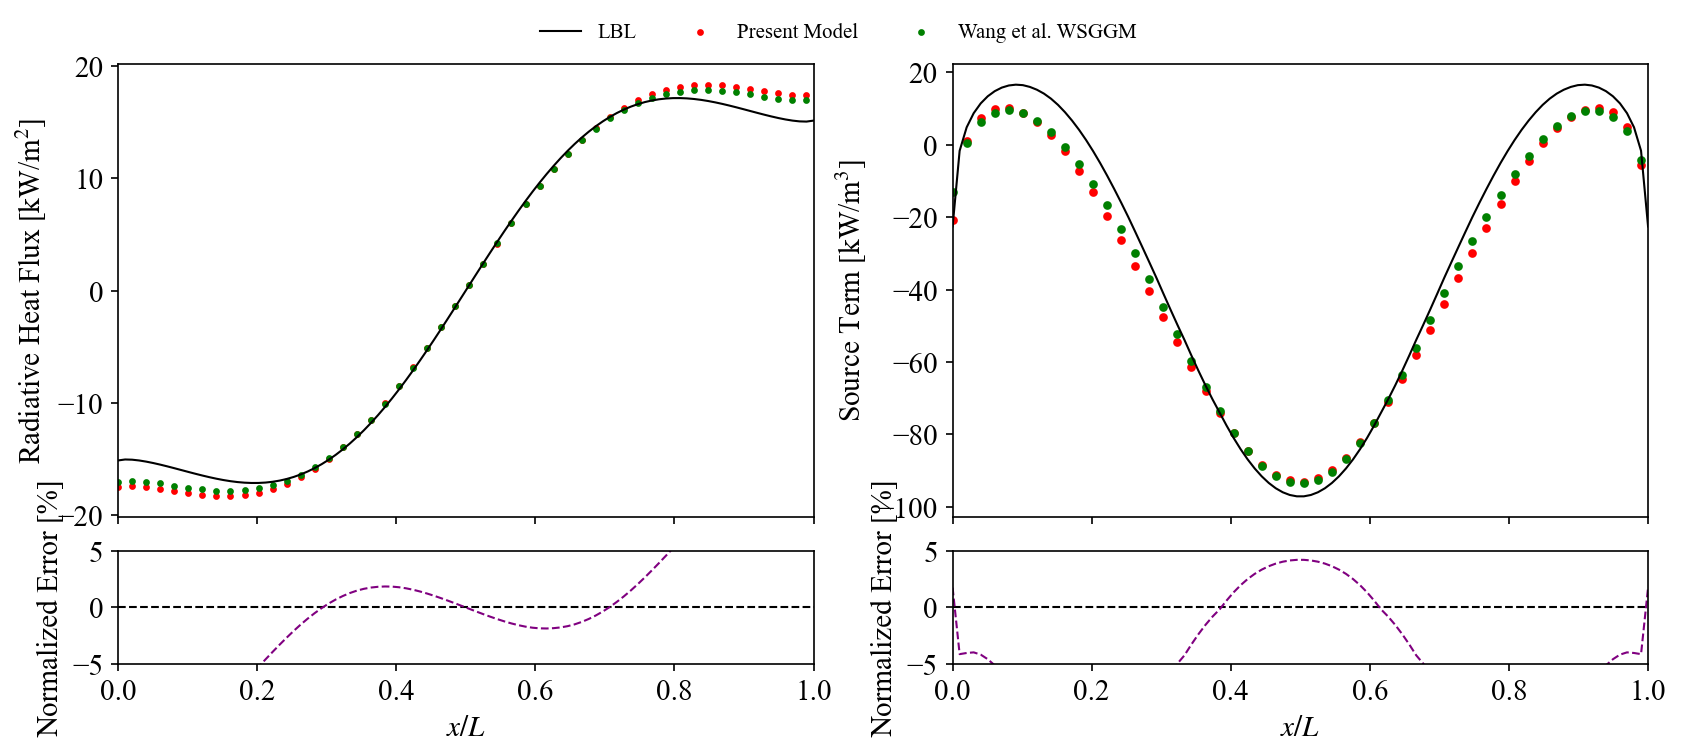

=== 工况 Case3.1_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 5.31%, 最大绝对误差: 14.01%
源项        - 平均绝对误差: 6.25%, 最大绝对误差: 11.74%
--------------------------------------------------


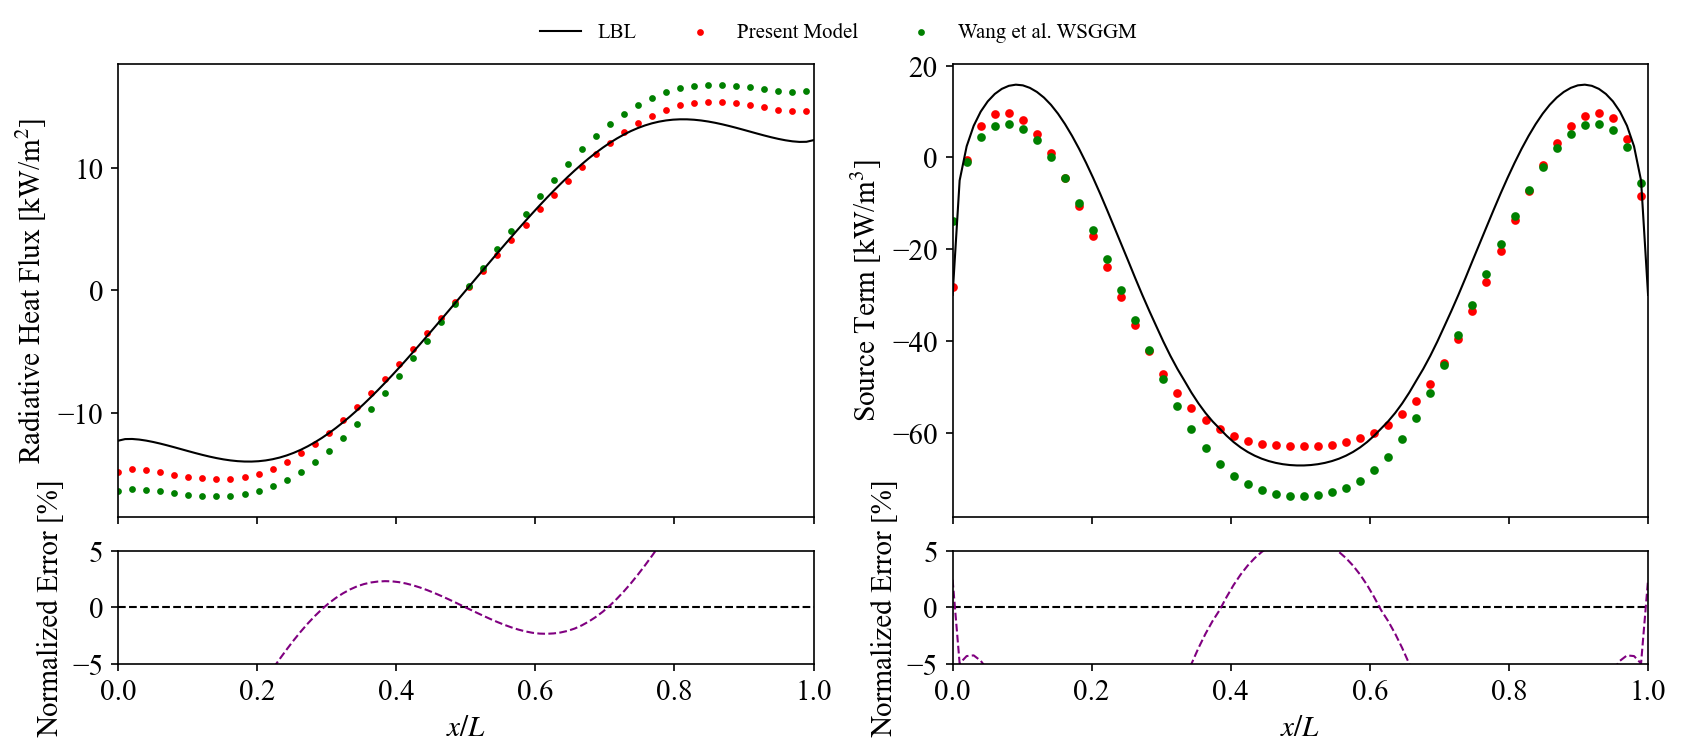

=== 工况 Case3.2_L1.0m 结果 ===
辐射热通量 - 平均绝对误差: 7.06%, 最大绝对误差: 18.09%
源项        - 平均绝对误差: 9.44%, 最大绝对误差: 18.78%
--------------------------------------------------


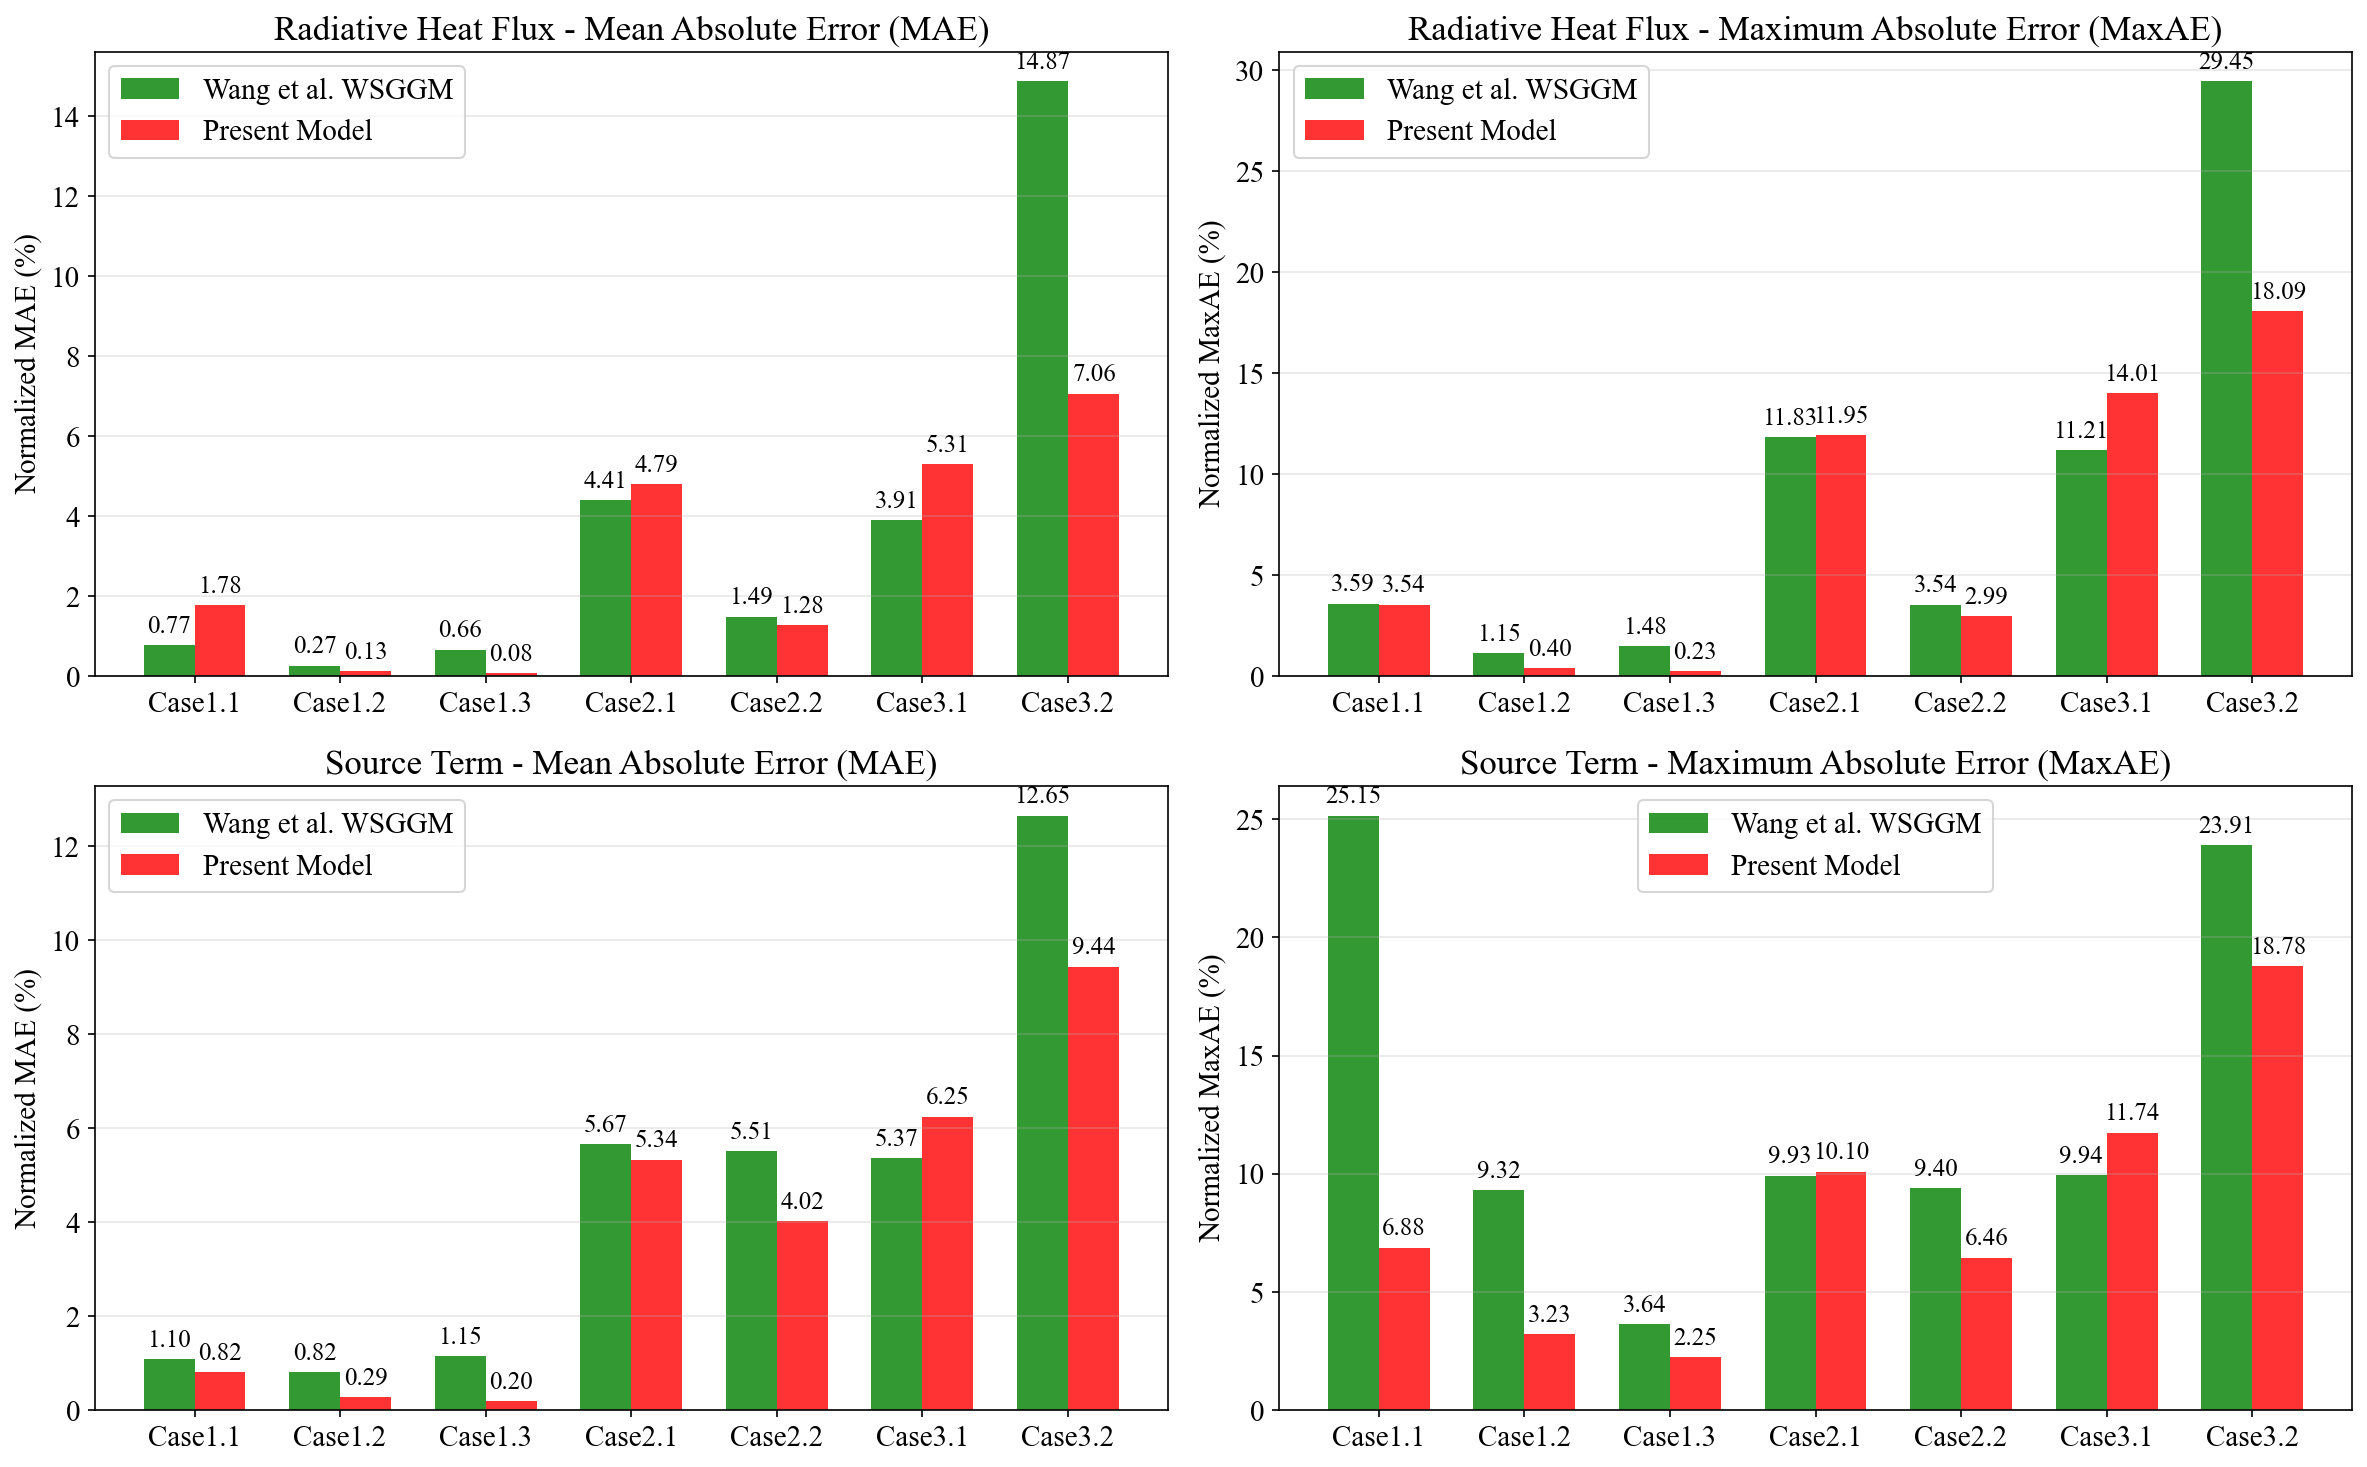


误差统计汇总
Case            Wang MAE(q)  RSM MAE(q)   Wang MAE(st) RSM MAE(st) 
------------------------------------------------------------
Case1.1_L1.0m   0.77         1.78         1.10         0.82        
Case1.2_L1.0m   0.27         0.13         0.82         0.29        
Case1.3_L1.0m   0.66         0.08         1.15         0.20        
Case2.1_L1.0m   4.41         4.79         5.67         5.34        
Case2.2_L1.0m   1.49         1.28         5.51         4.02        
Case3.1_L1.0m   3.91         5.31         5.37         6.25        
Case3.2_L1.0m   14.87        7.06         12.65        9.44        
------------------------------------------------------------
Average         3.77         2.92         4.61         3.77        


In [17]:
case_names = []
wang_mae_q_list = []
wang_maxae_q_list = []
wang_mae_st_list = []
wang_maxae_st_list = []

rsm_mae_q_list = []
rsm_maxae_q_list = []
rsm_mae_st_list = []
rsm_maxae_st_list = []

DATA_DIR = "../input/profiles"

# 获取所有.npy文件路径
case_files = glob.glob(os.path.join(DATA_DIR, "Case*.npy"))

# 遍历加载每个工况文件
for file_path in case_files:
    # 从文件名解析工况ID和长度参数
    filename = os.path.basename(file_path).replace(".npy", "")
    case_id, L_tag = filename.split("_")  # 示例: "Case1_L0.1m" → case_id="Case1", L_tag="L0.1m"
    L = float(L_tag[1:-1])  # 提取长度数值 (如 "L0.1m" → 0.1)
    
    # 加载当前工况数据 + LBL参考数据
    profile = np.load(file_path, allow_pickle=False)
    results = np.load(f"../results/{filename}.npy") / 1e3  # 假设LBL结果已存储为npy并缩放
    
    # --- 从profile中提取流场/物性数据 ---
    xs = profile['x']                # 空间坐标 [m]
    temperature_profiles = profile['T']      # 温度 [K]
    x_h2o_profiles = profile['Y_H2O']          # H2O摩尔分数
    x_nh3_profiles = profile['Y_NH3'] + 1e-4   # NH3摩尔分数（+1e-4避免数值问题）
    
    xss = np.vstack([x_h2o_profiles, x_nh3_profiles]).T  # 合并为二维数组供模型输入
    
    # --- 调用辐射模型计算RSM-WSGG结果 ---
    wang_q, wang_dq = wsgg_wang_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r)
    wang_q = wang_q / 1e3  # 单位转换为 kW/m²
    wang_dq = wang_dq / 1e3  # 单位转换为 kW/m³
    
    rsm_q, rsm_dq = wsgg_rsm_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r)
    rsm_q = rsm_q / 1e3  # 单位转换为 kW/m²
    rsm_dq = rsm_dq / 1e3  # 单位转换为 kW/m³
    
    # --- 创建2×2子图布局（热通量对比+误差、源项对比+误差）---
    fig, axs = plt.subplots(2, 2, figsize=(12, 5), dpi=150, 
                           gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.12})
    
    # -------------------- 辐射热通量对比（子图1：ax1） --------------------
    ax1 = axs[0, 0]
    ax1.plot(xs, results[:, 1], "k", label="LBL", linewidth=1.0)  # LBL热通量（注意符号）
    ax1.scatter(xs[::2], rsm_q[::2], color="red", marker="o", s=5, label="Present Model")  # RSM结果（采样点）
    ax1.scatter(xs[::2], wang_q[::2], color="green", marker="o", s=5, label="Wang et al. WSGGM")  # wang结果（采样点）
    ax1.set_ylabel(r"Radiative Heat Flux [kW/m$^2$]")
    # 移除ax1的图例
    # ax1.legend()  # 注释掉这行
    ax1.set_xlim([np.min(xs), np.max(xs)])
    plt.setp(ax1.get_xticklabels(), visible=False)  # 隐藏x轴刻度，避免重复
    
    # -------------------- 辐射热通量误差（子图2：ax2） --------------------
    ax2 = axs[1, 0]
    lbl_q = results[:, 1]  # LBL热通量（符号对齐）
    rsm_q = rsm_q      # RSM热通量（符号对齐）
    # 归一化误差公式：(预测值 - 参考值) / |参考值|的最大值 × 100%
    delta_q = (rsm_q - lbl_q) / np.max(np.abs(lbl_q)) * 100.0
    delta_q_wang = (wang_q - lbl_q) / np.max(np.abs(lbl_q)) * 100.0
    
    ax2.plot(xs, np.zeros_like(xs), "k--", linewidth=1.0)  # 零误差参考线
    ax2.plot(xs, delta_q, color="purple", linestyle="--", label="Present Model", linewidth=1.0)
    ax2.set_ylabel(r"Normalized Error [%]")
    ax2.set_xlabel(r"$x/L$")
    ax2.set_xlim([np.min(xs), np.max(xs)])
    ax2.set_ylim([-5, 5])  # 限制误差范围便于观察
    
    # --- 计算辐射热通量误差的统计量（平均绝对误差、最大绝对误差）---
    max_abs_error_q = np.max(np.abs(delta_q))   # 最大绝对误差
    mean_abs_error_q = np.mean(np.abs(delta_q)) # 平均绝对误差
    rsm_maxae_q = max_abs_error_q
    rsm_mae_q = mean_abs_error_q
    delta_q_wang = (wang_q - lbl_q) / np.max(np.abs(lbl_q)) * 100.0
    wang_maxae_q = np.max(np.abs(delta_q_wang))
    wang_mae_q = np.mean(np.abs(delta_q_wang))
    
    # -------------------- 源项对比（子图3：ax3） --------------------
    ax3 = axs[0, 1]
    ax3.plot(xs, -results[:, 2], "k", label="LBL", linewidth=1.0)  # LBL源项
    ax3.scatter(xs[::2], -rsm_dq[::2], color="red", marker="o", s=10, label="Present Model")  # RSM结果（采样点）
    ax3.scatter(xs[::2], -wang_dq[::2], color="green", marker="o", s=10, label="Wang et al. WSGGM")  # wang结果（采样点）
    ax3.set_ylabel(r"Source Term [kW/m$^3$]")
    # 移除ax3的图例
    # ax3.legend()  # 注释掉这行
    ax3.set_xlim([np.min(xs), np.max(xs)])
    plt.setp(ax3.get_xticklabels(), visible=False)  # 隐藏x轴刻度
    
    # -------------------- 源项误差（子图4：ax4） --------------------
    ax4 = axs[1, 1]
    lbl_st = -results[:, 2]  # LBL源项
    rsm_st = -rsm_dq    # RSM源项
    wang_st = -wang_dq  # wang源项
    # 归一化误差公式：(预测值 - 参考值) / |参考值|的最大值 × 100%
    delta_st = (rsm_st - lbl_st) / np.max(np.abs(lbl_st)) * 100.0
    delta_st_wang = (wang_st - lbl_st) / np.max(np.abs(lbl_st)) * 100.0
    
    ax4.plot(xs, np.zeros_like(xs), "k--", linewidth=1.0)  # 零误差参考线
    ax4.plot(xs, delta_st, color="purple", linestyle="--", label="Present Model", linewidth=1.0)
    ax4.set_ylabel(r"Normalized Error [%]")
    ax4.set_xlabel(r"$x/L$")
    ax4.set_xlim([np.min(xs), np.max(xs)])
    ax4.set_ylim([-5, 5])  # 限制误差范围便于观察
    
    # --- 计算源项误差的统计量（平均绝对误差、最大绝对误差）---
    max_abs_error_st = np.max(np.abs(delta_st))   # 最大绝对误差
    mean_abs_error_st = np.mean(np.abs(delta_st)) # 平均绝对误差
    rsm_maxae_st = max_abs_error_st
    rsm_mae_st = mean_abs_error_st
    delta_st_wang = (wang_st - lbl_st) / np.max(np.abs(lbl_st)) * 100.0
    wang_maxae_st = np.max(np.abs(delta_st_wang))
    wang_mae_st = np.mean(np.abs(delta_st_wang))

    # --- 创建共享图例，放在整个图的顶部中间 ---
    # 从任意一个子图获取图例句柄和标签（这里用ax1）
    handles, labels = ax1.get_legend_handles_labels()
    # 将图例放在整个图的顶部中间
    fig.legend(handles, labels, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 0.98),  # 调整y位置，使其更接近坐标图
               ncol=3, 
               fontsize=10,  # 稍微减小字体大小
               frameon=False)

    fig.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.90, hspace=0.12, wspace=0.2)
    
    # 收集误差数据
    case_names.append(filename)
    wang_mae_q_list.append(wang_mae_q)
    wang_maxae_q_list.append(wang_maxae_q)
    wang_mae_st_list.append(wang_mae_st)
    wang_maxae_st_list.append(wang_maxae_st)
    
    rsm_mae_q_list.append(rsm_mae_q)
    rsm_maxae_q_list.append(rsm_maxae_q)
    rsm_mae_st_list.append(rsm_mae_st)
    rsm_maxae_st_list.append(rsm_maxae_st)
    
    # --- 保存并显示图表 ---
    fig.savefig(f"../results/img/rsm_test_{filename}.png", bbox_inches="tight")
    plt.show()
    
    # --- 打印当前工况的误差统计结果 ---
    print(f"=== 工况 {filename} 结果 ===")
    print(f"辐射热通量 - 平均绝对误差: {mean_abs_error_q:.2f}%, 最大绝对误差: {max_abs_error_q:.2f}%")
    print(f"源项        - 平均绝对误差: {mean_abs_error_st:.2f}%, 最大绝对误差: {max_abs_error_st:.2f}%")
    print("-" * 50)

# 在循环结束后绘制汇总柱状图
if len(case_names) > 0:
    # 创建包含4个子图的柱状图汇总
    fig_bar, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)

    # 处理case names，只保留第一个下划线之前的部分
    simple_case_names = []
    for name in case_names:
        # 按第一个下划线分割，只取第一部分
        simple_name = name.split('_')[0]
        simple_case_names.append(simple_name)
    
    # 设置柱状图参数
    x = np.arange(len(case_names))  # 工况位置
    width = 0.35  # 柱宽
    
    # 1. 辐射热通量 - 平均绝对误差 (MAE)
    ax1 = axes[0, 0]
    rects1 = ax1.bar(x - width/2, wang_mae_q_list, width, label='Wang et al. WSGGM', color='green', alpha=0.8)
    rects2 = ax1.bar(x + width/2, rsm_mae_q_list, width, label='Present Model', color='red', alpha=0.8)
    
    ax1.set_ylabel('Normalized MAE (%)')
    ax1.set_title('Radiative Heat Flux - Mean Absolute Error (MAE)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(simple_case_names, ha='center')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 在柱子上方添加数值标签
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax1.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 垂直偏移
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12)
    
    # 2. 辐射热通量 - 最大绝对误差 (MaxAE)
    ax2 = axes[0, 1]
    rects3 = ax2.bar(x - width/2, wang_maxae_q_list, width, label='Wang et al. WSGGM', color='green', alpha=0.8)
    rects4 = ax2.bar(x + width/2, rsm_maxae_q_list, width, label='Present Model', color='red', alpha=0.8)
    
    ax2.set_ylabel('Normalized MaxAE (%)')
    ax2.set_title('Radiative Heat Flux - Maximum Absolute Error (MaxAE)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(simple_case_names, ha='center')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 在柱子上方添加数值标签
    for rects in [rects3, rects4]:
        for rect in rects:
            height = rect.get_height()
            ax2.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 垂直偏移
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12)
    
    # 3. 源项 - 平均绝对误差 (MAE)
    ax3 = axes[1, 0]
    rects5 = ax3.bar(x - width/2, wang_mae_st_list, width, label='Wang et al. WSGGM', color='green', alpha=0.8)
    rects6 = ax3.bar(x + width/2, rsm_mae_st_list, width, label='Present Model', color='red', alpha=0.8)
    
    ax3.set_ylabel('Normalized MAE (%)')
    ax3.set_title('Source Term - Mean Absolute Error (MAE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(simple_case_names, ha='center')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 在柱子上方添加数值标签
    for rects in [rects5, rects6]:
        for rect in rects:
            height = rect.get_height()
            ax3.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 垂直偏移
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12)
    
    # 4. 源项 - 最大绝对误差 (MaxAE)
    ax4 = axes[1, 1]
    rects7 = ax4.bar(x - width/2, wang_maxae_st_list, width, label='Wang et al. WSGGM', color='green', alpha=0.8)
    rects8 = ax4.bar(x + width/2, rsm_maxae_st_list, width, label='Present Model', color='red', alpha=0.8)
    
    ax4.set_ylabel('Normalized MaxAE (%)')
    ax4.set_title('Source Term - Maximum Absolute Error (MaxAE)')
    ax4.set_xticks(x)
    ax4.set_xticklabels(simple_case_names, ha='center')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 在柱子上方添加数值标签
    for rects in [rects7, rects8]:
        for rect in rects:
            height = rect.get_height()
            ax4.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 垂直偏移
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    fig_bar.savefig("../results/img/error_comparison_summary.png", bbox_inches="tight", dpi=150)
    plt.show()
    
    # 打印汇总统计
    print("\n" + "="*60)
    print("误差统计汇总")
    print("="*60)
    print(f"{'Case':<15} {'Wang MAE(q)':<12} {'RSM MAE(q)':<12} {'Wang MAE(st)':<12} {'RSM MAE(st)':<12}")
    print("-"*60)
    for i, case in enumerate(case_names):
        print(f"{case:<15} {wang_mae_q_list[i]:<12.2f} {rsm_mae_q_list[i]:<12.2f} "
              f"{wang_mae_st_list[i]:<12.2f} {rsm_mae_st_list[i]:<12.2f}")
    print("-"*60)
    print(f"{'Average':<15} {np.mean(wang_mae_q_list):<12.2f} {np.mean(rsm_mae_q_list):<12.2f} "
          f"{np.mean(wang_mae_st_list):<12.2f} {np.mean(rsm_mae_st_list):<12.2f}")
    print("="*60)

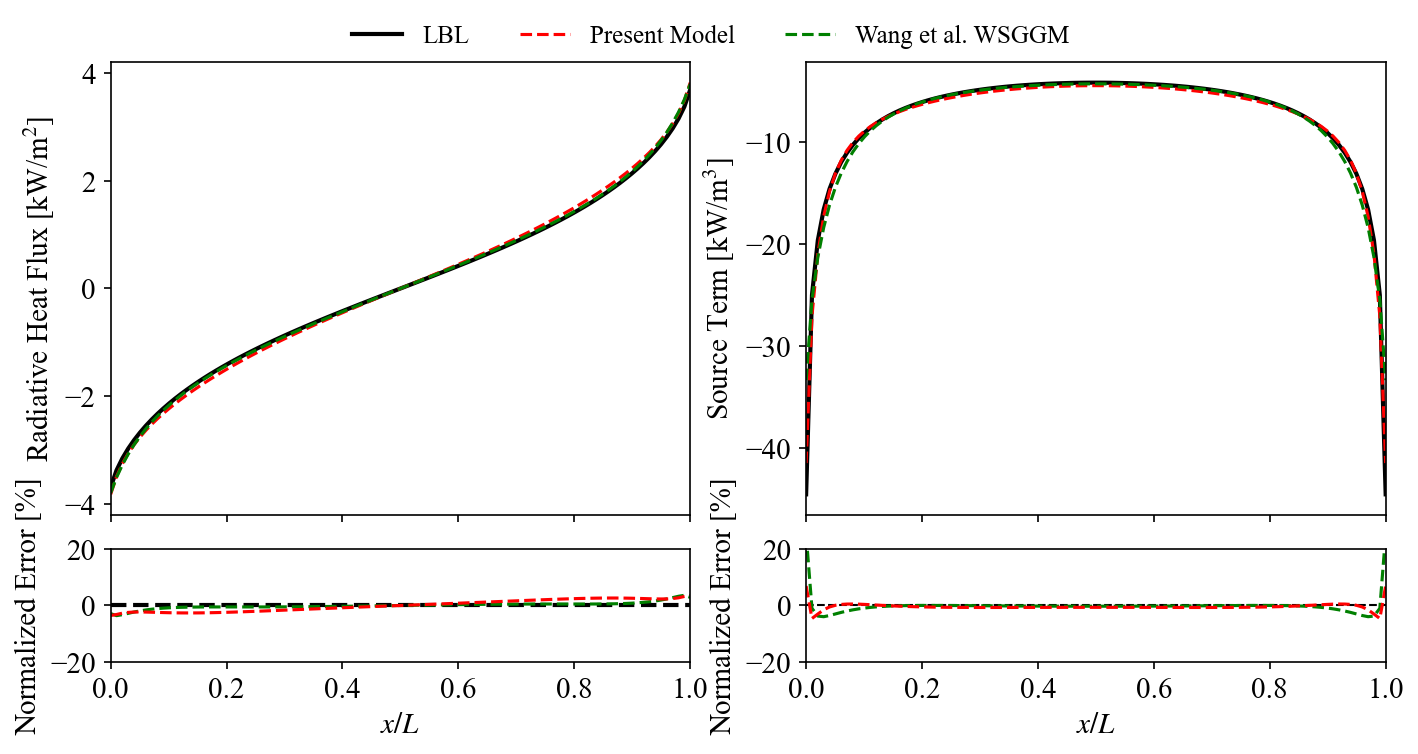

=== 工况 Case1.1_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=1.78%, 最大绝对误差=3.54%
RSM模型 - 源项: 平均绝对误差=0.82%, 最大绝对误差=6.88%
Wang模型 - 辐射热通量: 平均绝对误差=0.77%, 最大绝对误差=3.59%
Wang模型 - 源项: 平均绝对误差=1.10%, 最大绝对误差=25.15%
--------------------------------------------------


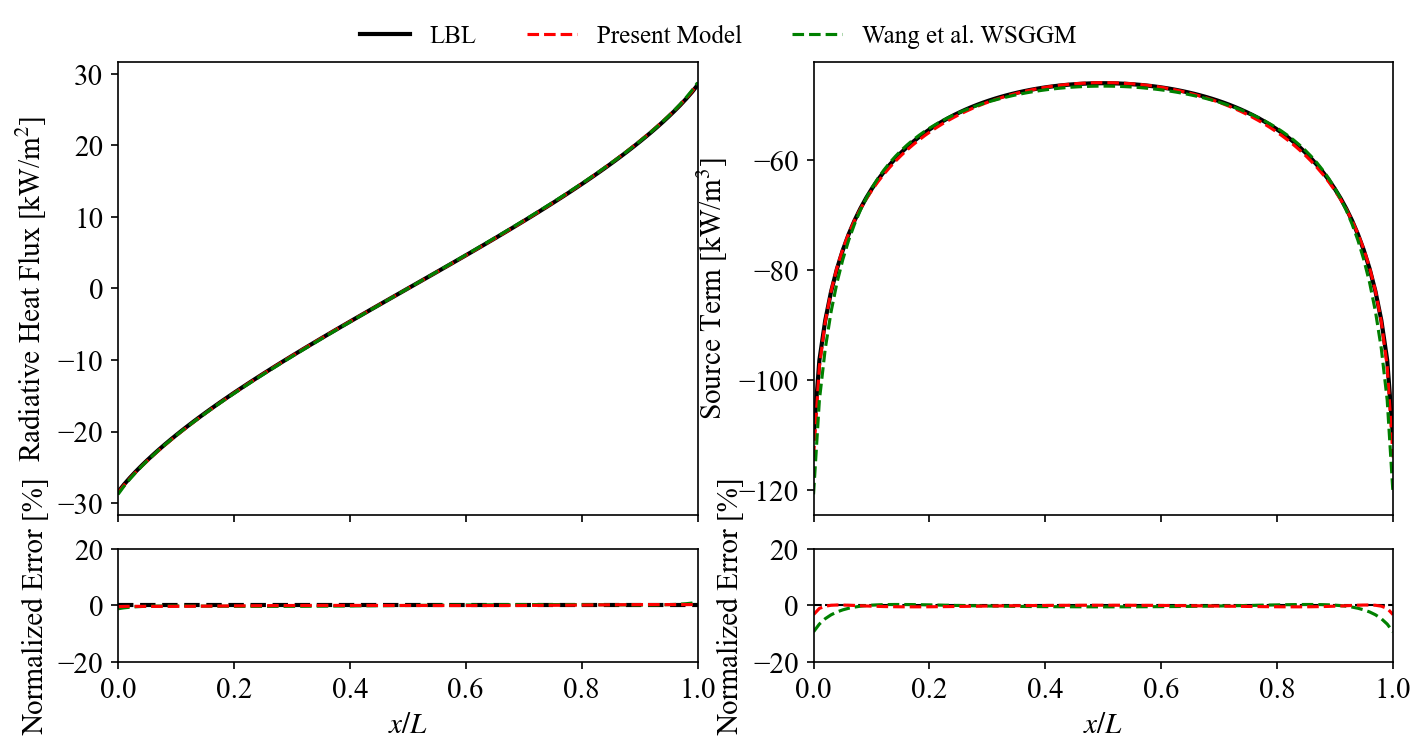

=== 工况 Case1.2_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=0.13%, 最大绝对误差=0.40%
RSM模型 - 源项: 平均绝对误差=0.29%, 最大绝对误差=3.23%
Wang模型 - 辐射热通量: 平均绝对误差=0.27%, 最大绝对误差=1.15%
Wang模型 - 源项: 平均绝对误差=0.82%, 最大绝对误差=9.32%
--------------------------------------------------


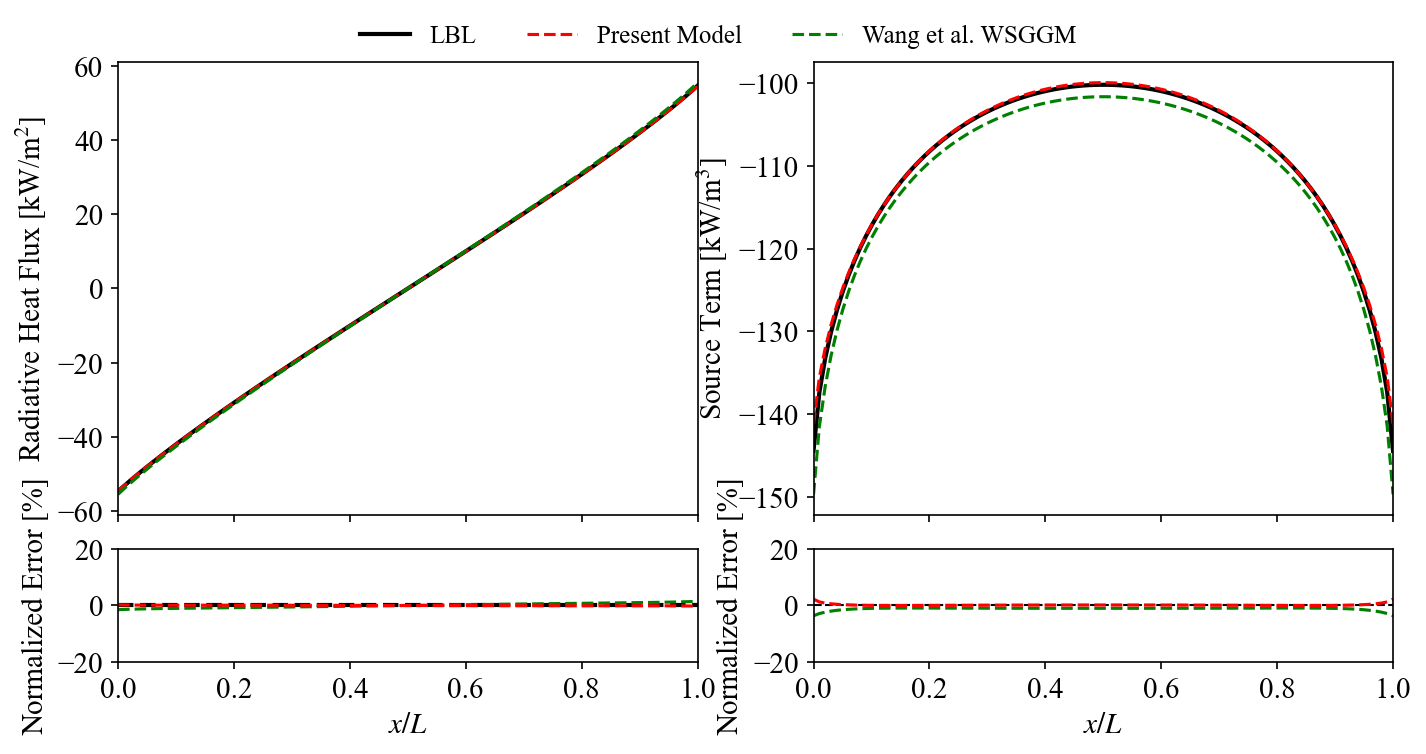

=== 工况 Case1.3_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=0.08%, 最大绝对误差=0.23%
RSM模型 - 源项: 平均绝对误差=0.20%, 最大绝对误差=2.25%
Wang模型 - 辐射热通量: 平均绝对误差=0.66%, 最大绝对误差=1.48%
Wang模型 - 源项: 平均绝对误差=1.15%, 最大绝对误差=3.64%
--------------------------------------------------


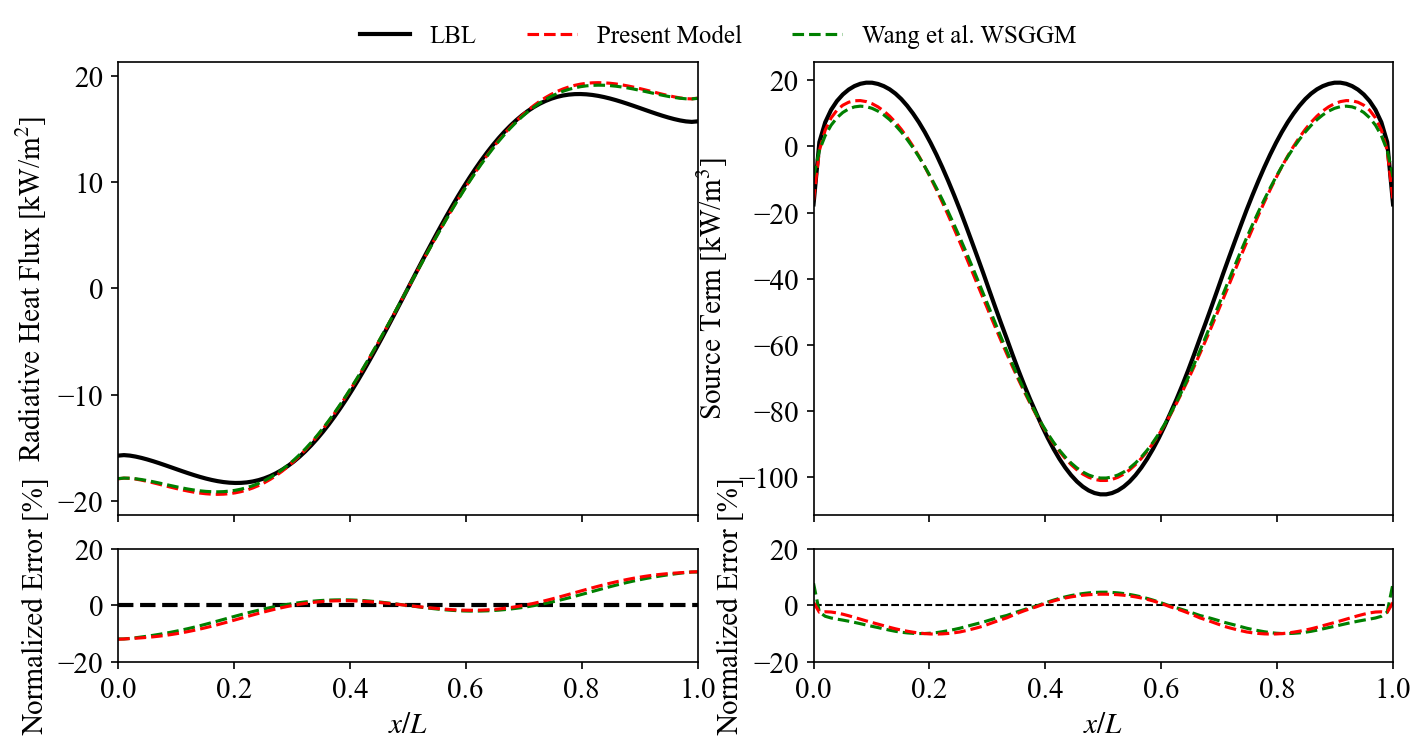

=== 工况 Case2.1_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=4.79%, 最大绝对误差=11.95%
RSM模型 - 源项: 平均绝对误差=5.34%, 最大绝对误差=10.10%
Wang模型 - 辐射热通量: 平均绝对误差=4.41%, 最大绝对误差=11.83%
Wang模型 - 源项: 平均绝对误差=5.67%, 最大绝对误差=9.93%
--------------------------------------------------


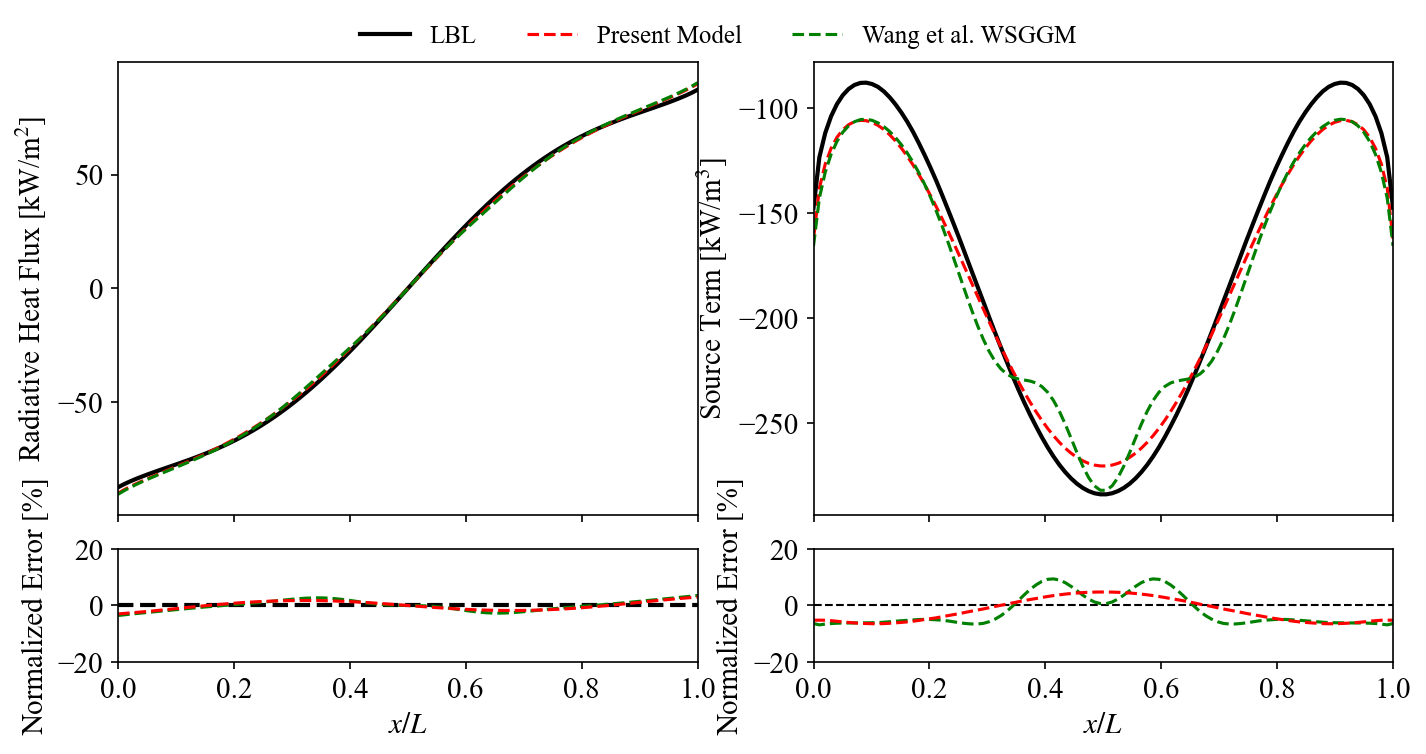

=== 工况 Case2.2_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=1.28%, 最大绝对误差=2.99%
RSM模型 - 源项: 平均绝对误差=4.02%, 最大绝对误差=6.46%
Wang模型 - 辐射热通量: 平均绝对误差=1.49%, 最大绝对误差=3.54%
Wang模型 - 源项: 平均绝对误差=5.51%, 最大绝对误差=9.40%
--------------------------------------------------


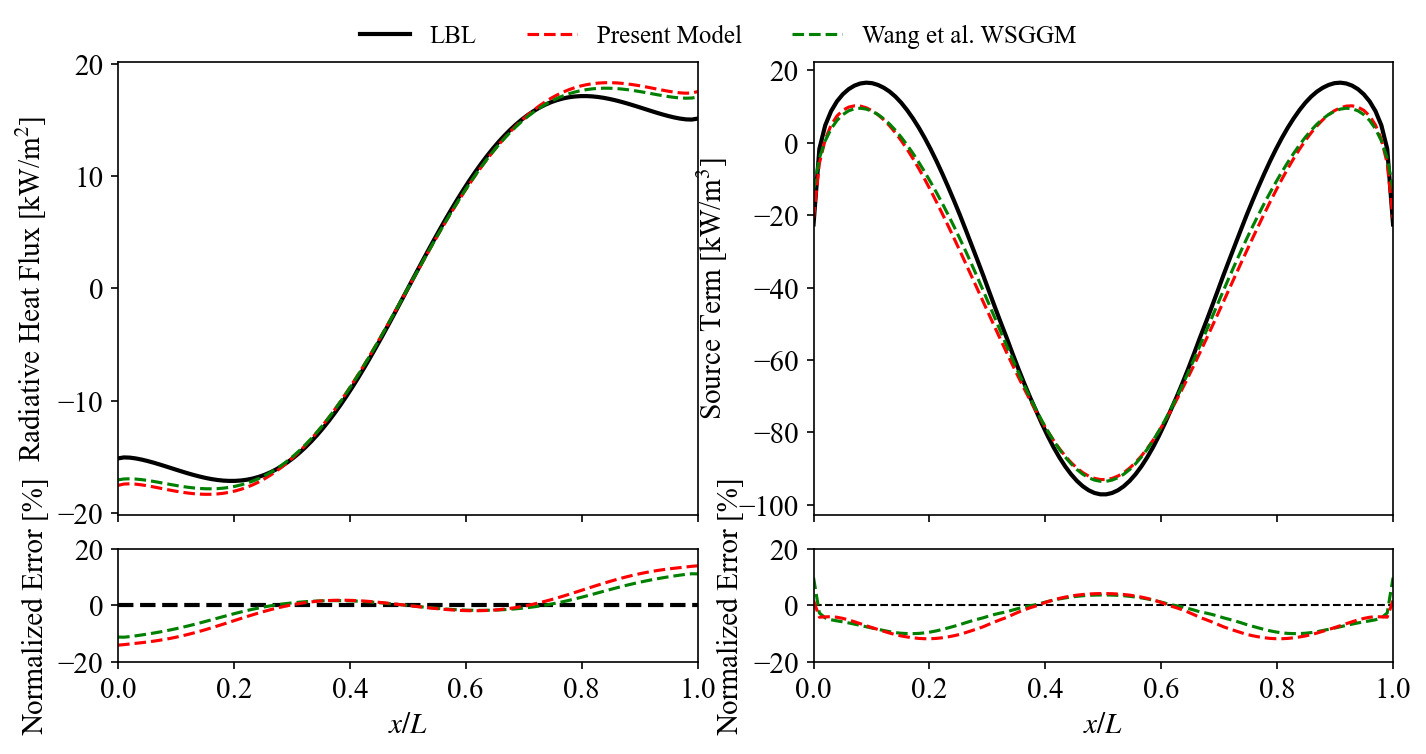

=== 工况 Case3.1_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=5.31%, 最大绝对误差=14.01%
RSM模型 - 源项: 平均绝对误差=6.25%, 最大绝对误差=11.74%
Wang模型 - 辐射热通量: 平均绝对误差=3.91%, 最大绝对误差=11.21%
Wang模型 - 源项: 平均绝对误差=5.37%, 最大绝对误差=9.94%
--------------------------------------------------


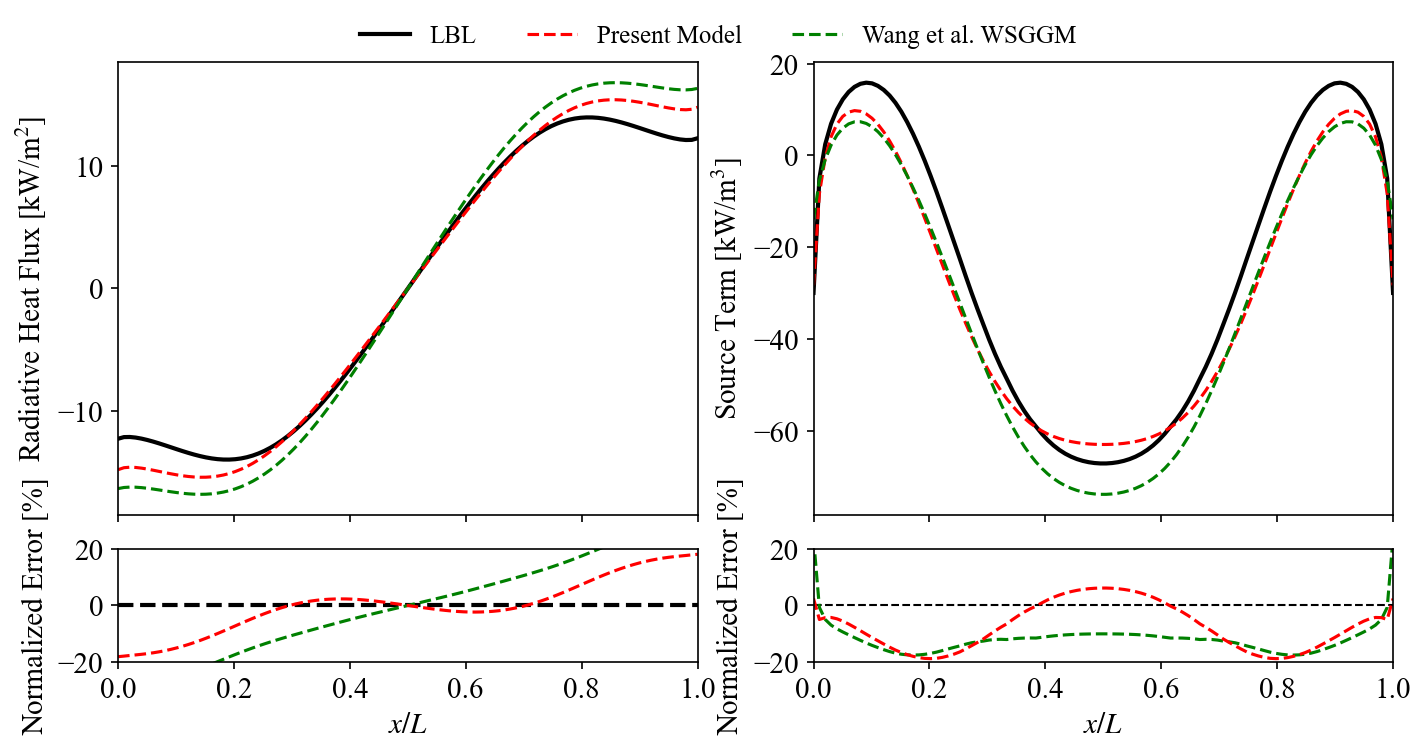

=== 工况 Case3.2_L1.0m 结果 ===
RSM模型 - 辐射热通量: 平均绝对误差=7.06%, 最大绝对误差=18.09%
RSM模型 - 源项: 平均绝对误差=9.44%, 最大绝对误差=18.78%
Wang模型 - 辐射热通量: 平均绝对误差=14.87%, 最大绝对误差=29.45%
Wang模型 - 源项: 平均绝对误差=12.65%, 最大绝对误差=23.91%
--------------------------------------------------


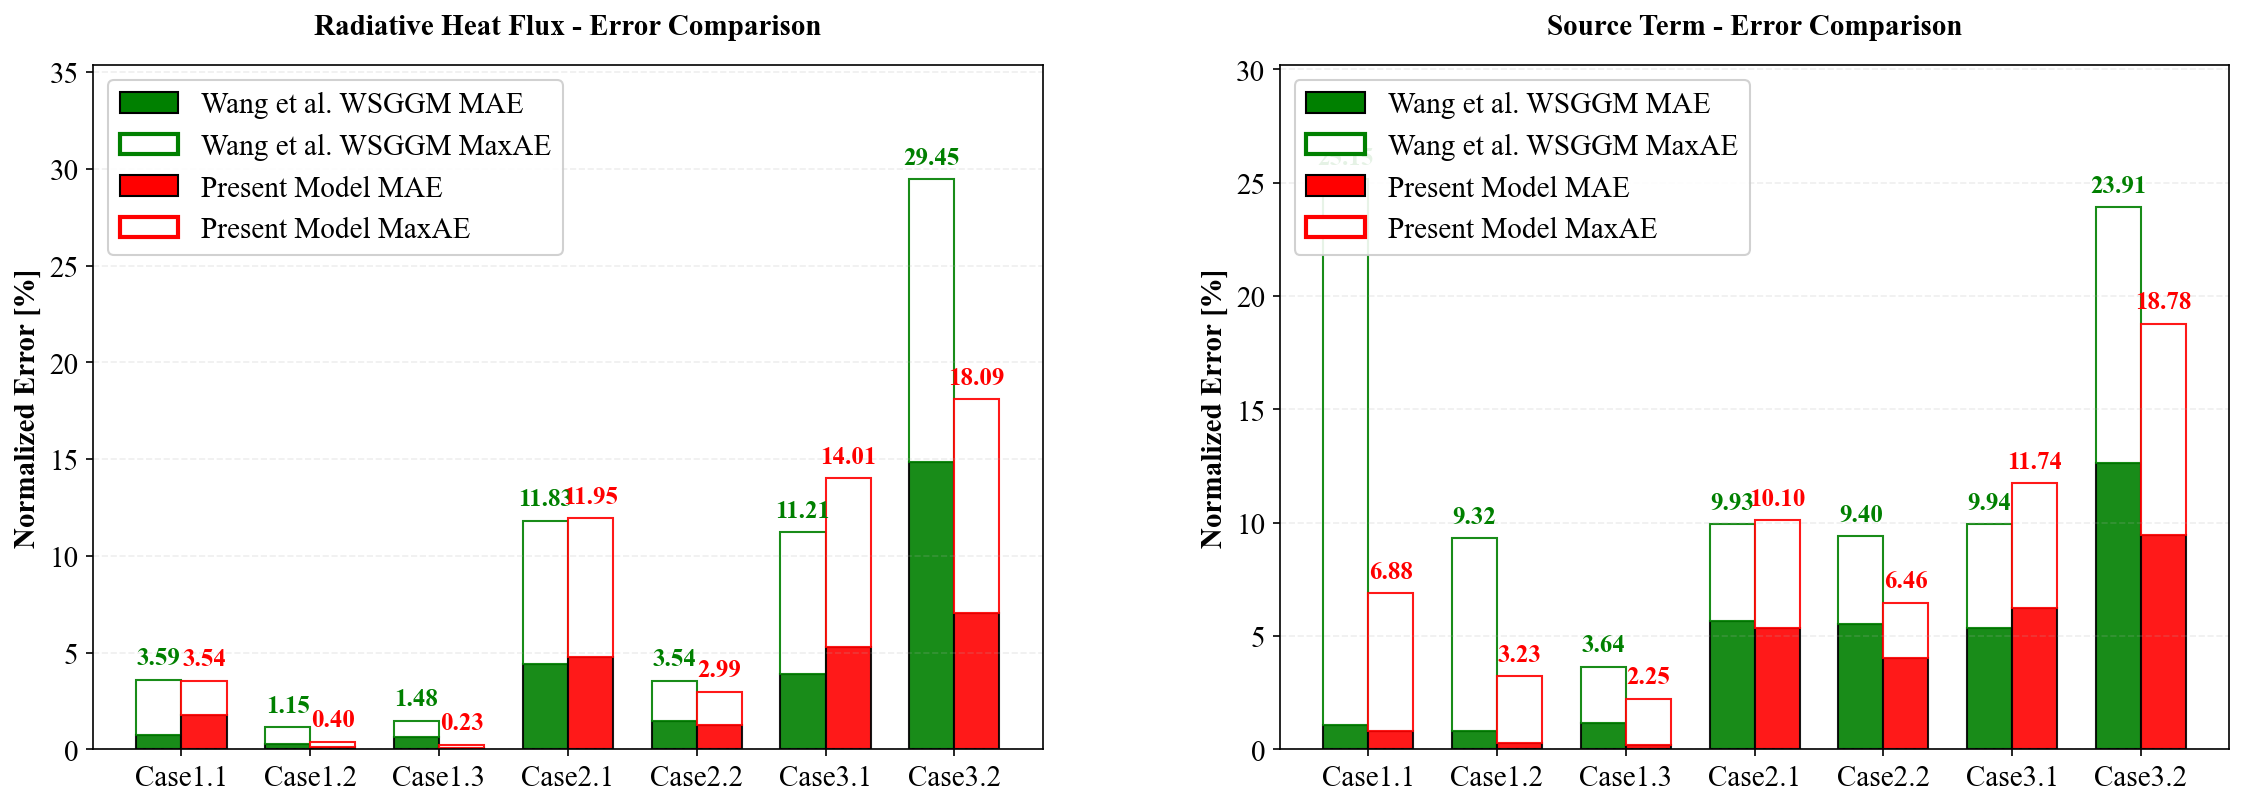


                           误差统计汇总                           
Case                 Wang et al. WSGGM MAE(q) Present Model MAE(q) Wang et al. WSGGM MAE(st) Present Model MAE(st)
--------------------------------------------------------------------------------
Case1.1_L1.0m        0.77         1.78         1.10         0.82        
Case1.2_L1.0m        0.27         0.13         0.82         0.29        
Case1.3_L1.0m        0.66         0.08         1.15         0.20        
Case2.1_L1.0m        4.41         4.79         5.67         5.34        
Case2.2_L1.0m        1.49         1.28         5.51         4.02        
Case3.1_L1.0m        3.91         5.31         5.37         6.25        
Case3.2_L1.0m        14.87        7.06         12.65        9.44        
--------------------------------------------------------------------------------
Average              3.77         2.92         4.61         3.77        

最大误差统计:
辐射热通量 MAE 最大误差: Wang=14.87%, RSM=7.06%
辐射热通量 MaxAE 最大误差: Wang=29.45%

In [18]:
case_names = []
wang_mae_q_list = []
wang_maxae_q_list = []
wang_mae_st_list = []
wang_maxae_st_list = []

rsm_mae_q_list = []
rsm_maxae_q_list = []
rsm_mae_st_list = []
rsm_maxae_st_list = []

DATA_DIR = "../input/profiles"

# 获取所有.npy文件路径
case_files = glob.glob(os.path.join(DATA_DIR, "Case*.npy"))

# 遍历加载每个工况文件
for file_path in case_files:
    # 从文件名解析工况ID和长度参数
    filename = os.path.basename(file_path).replace(".npy", "")
    case_id, L_tag = filename.split("_")  # 示例: "Case1_L0.1m" → case_id="Case1", L_tag="L0.1m"
    L = float(L_tag[1:-1])  # 提取长度数值 (如 "L0.1m" → 0.1)
    
    # 加载当前工况数据 + LBL参考数据
    profile = np.load(file_path, allow_pickle=False)
    results = np.load(f"../results/{filename}.npy") / 1e3  # 假设LBL结果已存储为npy并缩放
    
    # --- 从profile中提取流场/物性数据 ---
    xs = profile['x']                # 空间坐标 [m]
    temperature_profiles = profile['T']      # 温度 [K]
    x_h2o_profiles = profile['Y_H2O']          # H2O摩尔分数
    x_nh3_profiles = profile['Y_NH3'] + 1e-4   # NH3摩尔分数（+1e-4避免数值问题）
    
    xss = np.vstack([x_h2o_profiles, x_nh3_profiles]).T  # 合并为二维数组供模型输入
    
    # --- 调用辐射模型计算RSM-WSGG结果 ---
    wang_q, wang_dq = wsgg_wang_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r)
    wang_q = wang_q / 1e3  # 单位转换为 kW/m²
    wang_dq = wang_dq / 1e3  # 单位转换为 kW/m³
    
    rsm_q, rsm_dq = wsgg_rsm_cal(xs, temperature_profiles, x_h2o_profiles, x_nh3_profiles, T_l, T_r)
    rsm_q = rsm_q / 1e3  # 单位转换为 kW/m²
    rsm_dq = rsm_dq / 1e3  # 单位转换为 kW/m³
    
    # --- 创建2×2子图布局（热通量对比+误差、源项对比+误差）---
    fig, axs = plt.subplots(2, 2, figsize=(10, 5), dpi=150, 
                           gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.12})
    
    # -------------------- 辐射热通量对比（子图1：ax1） --------------------
    ax1 = axs[0, 0]
    ax1.plot(xs, results[:, 1], "k", label="LBL", linewidth=2.0)  # LBL热通量（注意符号）
    # 改为虚线显示
    ax1.plot(xs, rsm_q, color="red", linestyle="--", linewidth=1.5, label="Present Model")  # RSM结果（虚线）
    ax1.plot(xs, wang_q, color="green", linestyle="--", linewidth=1.5, label="Wang et al. WSGGM")  # wang结果（虚线）
    ax1.set_ylabel(r"Radiative Heat Flux [kW/m$^2$]")
    # 移除ax1的图例
    # ax1.legend()  # 注释掉这行
    ax1.set_xlim([np.min(xs), np.max(xs)])
    plt.setp(ax1.get_xticklabels(), visible=False)  # 隐藏x轴刻度，避免重复
    
    # -------------------- 辐射热通量误差（子图2：ax2） --------------------
    ax2 = axs[1, 0]
    lbl_q = results[:, 1]  # LBL热通量（符号对齐）
    rsm_q = rsm_q      # RSM热通量（符号对齐）
    wang_q = wang_q    # wang热通量（符号对齐）
    
    # 归一化误差公式：(预测值 - 参考值) / |参考值|的最大值 × 100%
    delta_q_rsm = (rsm_q - lbl_q) / np.max(np.abs(lbl_q)) * 100.0
    delta_q_wang = (wang_q - lbl_q) / np.max(np.abs(lbl_q)) * 100.0
    
    ax2.plot(xs, np.zeros_like(xs), "k--", linewidth=2.0)  # 零误差参考线
    # 增加wang模型误差曲线，颜色与主图对应
    ax2.plot(xs, delta_q_wang, color="green", linestyle="--", linewidth=1.5)  # 绿色，与wang模型对应
    ax2.plot(xs, delta_q_rsm, color="red", linestyle="--", linewidth=1.5)  # 红色，与present model对应
    
    ax2.set_ylabel(r"Normalized Error [%]")
    ax2.set_xlabel(r"$x/L$")
    ax2.set_xlim([np.min(xs), np.max(xs)])
    ax2.set_ylim([-20, 20])  # 限制误差范围便于观察
    
    # --- 计算辐射热通量误差的统计量（平均绝对误差、最大绝对误差）---
    max_abs_error_q_rsm = np.max(np.abs(delta_q_rsm))   # 最大绝对误差
    mean_abs_error_q_rsm = np.mean(np.abs(delta_q_rsm)) # 平均绝对误差
    rsm_maxae_q = max_abs_error_q_rsm
    rsm_mae_q = mean_abs_error_q_rsm
    
    max_abs_error_q_wang = np.max(np.abs(delta_q_wang))
    mean_abs_error_q_wang = np.mean(np.abs(delta_q_wang))
    wang_maxae_q = max_abs_error_q_wang
    wang_mae_q = mean_abs_error_q_wang
    
    # -------------------- 源项对比（子图3：ax3） --------------------
    ax3 = axs[0, 1]
    ax3.plot(xs, -results[:, 2], "k", label="LBL", linewidth=2.0)  # LBL源项
    # 改为虚线显示
    ax3.plot(xs, -rsm_dq, color="red", linestyle="--", linewidth=1.5, label="Present Model")  # RSM结果（虚线）
    ax3.plot(xs, -wang_dq, color="green", linestyle="--", linewidth=1.5, label="Wang et al. WSGGM")  # wang结果（虚线）
    ax3.set_ylabel(r"Source Term [kW/m$^3$]")
    # 移除ax3的图例
    # ax3.legend()  # 注释掉这行
    ax3.set_xlim([np.min(xs), np.max(xs)])
    plt.setp(ax3.get_xticklabels(), visible=False)  # 隐藏x轴刻度
    
    # -------------------- 源项误差（子图4：ax4） --------------------
    ax4 = axs[1, 1]
    lbl_st = -results[:, 2]  # LBL源项
    rsm_st = -rsm_dq    # RSM源项
    wang_st = -wang_dq  # wang源项
    
    # 归一化误差公式：(预测值 - 参考值) / |参考值|的最大值 × 100%
    delta_st_rsm = (rsm_st - lbl_st) / np.max(np.abs(lbl_st)) * 100.0
    delta_st_wang = (wang_st - lbl_st) / np.max(np.abs(lbl_st)) * 100.0
    
    ax4.plot(xs, np.zeros_like(xs), "k--", linewidth=1.0)  # 零误差参考线
    # 增加wang模型误差曲线，颜色与主图对应
    ax4.plot(xs, delta_st_wang, color="green", linestyle="--", linewidth=1.5)  # 绿色，与wang模型对应
    ax4.plot(xs, delta_st_rsm, color="red", linestyle="--", linewidth=1.5)  # 红色，与present model对应
    
    ax4.set_ylabel(r"Normalized Error [%]")
    ax4.set_xlabel(r"$x/L$")
    ax4.set_xlim([np.min(xs), np.max(xs)])
    ax4.set_ylim([-20, 20])  # 限制误差范围便于观察
    
    # --- 计算源项误差的统计量（平均绝对误差、最大绝对误差）---
    max_abs_error_st_rsm = np.max(np.abs(delta_st_rsm))   # 最大绝对误差
    mean_abs_error_st_rsm = np.mean(np.abs(delta_st_rsm)) # 平均绝对误差
    rsm_maxae_st = max_abs_error_st_rsm
    rsm_mae_st = mean_abs_error_st_rsm
    
    max_abs_error_st_wang = np.max(np.abs(delta_st_wang))
    mean_abs_error_st_wang = np.mean(np.abs(delta_st_wang))
    wang_maxae_st = max_abs_error_st_wang
    wang_mae_st = mean_abs_error_st_wang

    # --- 创建共享图例，放在整个图的顶部中间 ---
    # 从任意一个子图获取图例句柄和标签（这里用ax1）
    handles, labels = ax1.get_legend_handles_labels()
    # 将图例放在整个图的顶部中间
    fig.legend(handles, labels, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 0.98),  # 调整y位置，使其更接近坐标图
               ncol=3, 
               fontsize=12,  # 稍微减小字体大小
               frameon=False)

    fig.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.90, hspace=0.12, wspace=0.2)
    
    # 收集误差数据
    case_names.append(filename)
    wang_mae_q_list.append(wang_mae_q)
    wang_maxae_q_list.append(wang_maxae_q)
    wang_mae_st_list.append(wang_mae_st)
    wang_maxae_st_list.append(wang_maxae_st)
    
    rsm_mae_q_list.append(rsm_mae_q)
    rsm_maxae_q_list.append(rsm_maxae_q)
    rsm_mae_st_list.append(rsm_mae_st)
    rsm_maxae_st_list.append(rsm_maxae_st)
    
    # --- 保存并显示图表 ---
    fig.savefig(f"../results/img/rsm_test_{filename}.png", bbox_inches="tight")
    plt.show()
    
    # --- 打印当前工况的误差统计结果 ---
    print(f"=== 工况 {filename} 结果 ===")
    print(f"RSM模型 - 辐射热通量: 平均绝对误差={mean_abs_error_q_rsm:.2f}%, 最大绝对误差={max_abs_error_q_rsm:.2f}%")
    print(f"RSM模型 - 源项: 平均绝对误差={mean_abs_error_st_rsm:.2f}%, 最大绝对误差={max_abs_error_st_rsm:.2f}%")
    print(f"Wang模型 - 辐射热通量: 平均绝对误差={mean_abs_error_q_wang:.2f}%, 最大绝对误差={max_abs_error_q_wang:.2f}%")
    print(f"Wang模型 - 源项: 平均绝对误差={mean_abs_error_st_wang:.2f}%, 最大绝对误差={max_abs_error_st_wang:.2f}%")
    print("-" * 50)

# 在循环结束后绘制汇总柱状图
if len(case_names) > 0:
    # 设置全局字体大小为12
    plt.rcParams.update({'font.size': 14})
    
    # 创建包含2个子图的柱状图汇总
    fig_bar, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
    
    # 处理case names，只保留第一个下划线之前的部分
    simple_case_names = []
    for name in case_names:
        # 按第一个下划线分割，只取第一部分
        simple_name = name.split('_')[0]
        simple_case_names.append(simple_name)
    
    # 设置柱状图参数
    x = np.arange(len(simple_case_names))  # 工况位置
    width = 0.35  # 柱宽
    
    # 设置颜色 - 使用红绿配色
    wang_color = 'green'  # 绿色 - Wang
    rsm_color = 'red'     # 红色 - RSM
    edge_color = 'black'  # 边框颜色
    
    # 1. 辐射热通量误差对比
    ax1 = axes[0]
    
    # 计算每个模型的MAE和MaxAE差值（用于空心部分）
    wang_q_diff = [max(0, wang_maxae_q_list[i] - wang_mae_q_list[i]) for i in range(len(case_names))]
    rsm_q_diff = [max(0, rsm_maxae_q_list[i] - rsm_mae_q_list[i]) for i in range(len(case_names))]
    
    # 绘制Wang模型柱子 - 底部实心部分（MAE）
    wang_mae_bars = ax1.bar(x - width/2, wang_mae_q_list, width, 
                           color=wang_color, alpha=0.9, 
                           edgecolor=edge_color, linewidth=1,
                           label='Wang MAE')
    
    # 绘制Wang模型柱子 - 顶部空心部分（MaxAE - MAE） - 去掉剖面线
    wang_maxae_bars = ax1.bar(x - width/2, wang_q_diff, width,
                             bottom=wang_mae_q_list,
                             color='white', alpha=0.9,
                             edgecolor=wang_color, linewidth=1,
                             label='Wang MaxAE')
    
    # 绘制RSM模型柱子 - 底部实心部分（MAE）
    rsm_mae_bars = ax1.bar(x + width/2, rsm_mae_q_list, width,
                          color=rsm_color, alpha=0.9,
                          edgecolor=edge_color, linewidth=1,
                          label='RSM MAE')
    
    # 绘制RSM模型柱子 - 顶部空心部分（MaxAE - MAE） - 去掉剖面线
    rsm_maxae_bars = ax1.bar(x + width/2, rsm_q_diff, width,
                            bottom=rsm_mae_q_list,
                            color='white', alpha=0.9,
                            edgecolor=rsm_color, linewidth=1,
                            label='RSM MaxAE')
    
    ax1.set_ylabel('Normalized Error [%]', fontsize=14, fontweight='bold')
    ax1.set_title('Radiative Heat Flux - Error Comparison', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(simple_case_names, ha='center', fontsize=14)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    
    # 创建自定义图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=wang_color, edgecolor=edge_color, label='Wang et al. WSGGM MAE'),
        Patch(facecolor='white', edgecolor=wang_color, linewidth=2, label='Wang et al. WSGGM MaxAE'),
        Patch(facecolor=rsm_color, edgecolor=edge_color, label='Present Model MAE'),
        Patch(facecolor='white', edgecolor=rsm_color, linewidth=2, label='Present Model MaxAE')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', fontsize=14, framealpha=0.9)
    
    ax1.grid(True, alpha=0.2, axis='y', linestyle='--')
    
    # 设置y轴范围
    max_y1 = max(max(wang_maxae_q_list), max(rsm_maxae_q_list))
    ax1.set_ylim([0, max_y1 * 1.2])
    
    # 在柱子上方添加MaxAE数值标签
    for i in range(len(simple_case_names)):
        # Wang MaxAE标签
        ax1.annotate(f'{wang_maxae_q_list[i]:.2f}',
                    xy=(x[i] - width/2, wang_maxae_q_list[i]),
                    xytext=(0, 5),  # 垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12,
                    fontweight='bold', color=wang_color)
        
        # RSM MaxAE标签
        ax1.annotate(f'{rsm_maxae_q_list[i]:.2f}',
                    xy=(x[i] + width/2, rsm_maxae_q_list[i]),
                    xytext=(0, 5),  # 垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12,
                    fontweight='bold', color=rsm_color)
        
        # 在柱子内部添加MAE数值标签
        # if wang_mae_q_list[i] > 0:
        #     ax1.annotate(f'{wang_mae_q_list[i]:.2f}',
        #                 xy=(x[i] - width/2, wang_mae_q_list[i]/2),
        #                 xytext=(0, 0),  # 垂直偏移
        #                 textcoords="offset points",
        #                 ha='center', va='center', fontsize=12,
        #                 fontweight='bold', color='white')
        
        # if rsm_mae_q_list[i] > 0:
        #     ax1.annotate(f'{rsm_mae_q_list[i]:.2f}',
        #                 xy=(x[i] + width/2, rsm_mae_q_list[i]/2),
        #                 xytext=(0, 0),  # 垂直偏移
        #                 textcoords="offset points",
        #                 ha='center', va='center', fontsize=12,
        #                 fontweight='bold', color='white')
    
    # 2. 源项误差对比
    ax2 = axes[1]
    
    # 计算每个模型的MAE和MaxAE差值（用于空心部分）
    wang_st_diff = [max(0, wang_maxae_st_list[i] - wang_mae_st_list[i]) for i in range(len(case_names))]
    rsm_st_diff = [max(0, rsm_maxae_st_list[i] - rsm_mae_st_list[i]) for i in range(len(case_names))]
    
    # 绘制Wang模型柱子 - 底部实心部分（MAE）
    wang_mae_st_bars = ax2.bar(x - width/2, wang_mae_st_list, width, 
                              color=wang_color, alpha=0.9, 
                              edgecolor=edge_color, linewidth=1)
    
    # 绘制Wang模型柱子 - 顶部空心部分（MaxAE - MAE）
    wang_maxae_st_bars = ax2.bar(x - width/2, wang_st_diff, width,
                                bottom=wang_mae_st_list,
                                color='white', alpha=0.9,
                                edgecolor=wang_color, linewidth=1)
    
    # 绘制RSM模型柱子 - 底部实心部分（MAE）
    rsm_mae_st_bars = ax2.bar(x + width/2, rsm_mae_st_list, width,
                             color=rsm_color, alpha=0.9,
                             edgecolor=edge_color, linewidth=1)
    
    # 绘制RSM模型柱子 - 顶部空心部分（MaxAE - MAE）
    rsm_maxae_st_bars = ax2.bar(x + width/2, rsm_st_diff, width,
                               bottom=rsm_mae_st_list,
                               color='white', alpha=0.9,
                               edgecolor=rsm_color, linewidth=1)
    
    ax2.set_ylabel('Normalized Error [%]', fontsize=14, fontweight='bold')
    ax2.set_title('Source Term - Error Comparison', fontsize=14, fontweight='bold', pad=15)
    # ax2.set_xlabel('Case', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(simple_case_names, ha='center', fontsize=14)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=14, framealpha=0.9)
    ax2.grid(True, alpha=0.2, axis='y', linestyle='--')
    
    # 设置y轴范围
    max_y2 = max(max(wang_maxae_st_list), max(rsm_maxae_st_list))
    ax2.set_ylim([0, max_y2 * 1.2])
    
    # 在柱子上方添加MaxAE数值标签
    for i in range(len(simple_case_names)):
        # Wang MaxAE标签
        ax2.annotate(f'{wang_maxae_st_list[i]:.2f}',
                    xy=(x[i] - width/2, wang_maxae_st_list[i]),
                    xytext=(0, 5),  # 垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12,
                    fontweight='bold', color=wang_color)
        
        # RSM MaxAE标签
        ax2.annotate(f'{rsm_maxae_st_list[i]:.2f}',
                    xy=(x[i] + width/2, rsm_maxae_st_list[i]),
                    xytext=(0, 5),  # 垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12,
                    fontweight='bold', color=rsm_color)
        
        # 在柱子内部添加MAE数值标签
        # if wang_mae_st_list[i] > 0:
        #     ax2.annotate(f'{wang_mae_st_list[i]:.2f}',
        #                 xy=(x[i] - width/2, wang_mae_st_list[i]/2),
        #                 xytext=(0, 0),  # 垂直偏移
        #                 textcoords="offset points",
        #                 ha='center', va='center', fontsize=12,
        #                 fontweight='bold', color='white')
        
        # if rsm_mae_st_list[i] > 0:
        #     ax2.annotate(f'{rsm_mae_st_list[i]:.2f}',
        #                 xy=(x[i] + width/2, rsm_mae_st_list[i]/2),
        #                 xytext=(0, 0),  # 垂直偏移
        #                 textcoords="offset points",
        #                 ha='center', va='center', fontsize=12,
        #                 fontweight='bold', color='white')
    
    # 调整子图间距
    plt.subplots_adjust(left=0.08, right=0.97, bottom=0.12, top=0.88, 
                       wspace=0.25)
    
    # 添加整体标题
    # fig_bar.suptitle('Error Comparison: Wang et al. WSGGM vs Present Model (MAE and MaxAE)', 
                    # fontsize=12, fontweight='bold', y=0.95)
    
    # 保存图表
    fig_bar.savefig("../results/img/error_comparison_summary_combined.png", bbox_inches="tight", dpi=300)
    plt.show()
    
    # 打印汇总统计
    print("\n" + "="*80)
    print("误差统计汇总".center(60))
    print("="*80)
    print(f"{'Case':<20} {'Wang et al. WSGGM MAE(q)':<12} {'Present Model MAE(q)':<12} {'Wang et al. WSGGM MAE(st)':<12} {'Present Model MAE(st)':<12}")
    print("-"*80)
    for i, case in enumerate(case_names):
        print(f"{case:<20} {wang_mae_q_list[i]:<12.2f} {rsm_mae_q_list[i]:<12.2f} "
              f"{wang_mae_st_list[i]:<12.2f} {rsm_mae_st_list[i]:<12.2f}")
    print("-"*80)
    print(f"{'Average':<20} {np.mean(wang_mae_q_list):<12.2f} {np.mean(rsm_mae_q_list):<12.2f} "
          f"{np.mean(wang_mae_st_list):<12.2f} {np.mean(rsm_mae_st_list):<12.2f}")
    print("="*80)
    
    # 打印最大误差统计
    print("\n最大误差统计:")
    print(f"辐射热通量 MAE 最大误差: Wang={max(wang_mae_q_list):.2f}%, RSM={max(rsm_mae_q_list):.2f}%")
    print(f"辐射热通量 MaxAE 最大误差: Wang={max(wang_maxae_q_list):.2f}%, RSM={max(rsm_maxae_q_list):.2f}%")
    print(f"源项 MAE 最大误差: Wang={max(wang_mae_st_list):.2f}%, RSM={max(rsm_mae_st_list):.2f}%")
    print(f"源项 MaxAE 最大误差: Wang={max(wang_maxae_st_list):.2f}%, RSM={max(rsm_maxae_st_list):.2f}%")